In [2]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
NA = 0.1
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

[1.47e+08 1.40e+08]


In [2]:
transitions_full = pd.read_csv("Ca_level_info.csv",sep = ",",encoding = "UTF-8")
linewidths_full = np.array(transitions_full["A_ki (s^-1)"])
lambda_res_full = np.array(transitions_full["wavelength (nm)"])*1e-9
omega_res_full = 2*pi*c/lambda_res_full
linewidths_full

array([2.58e+07, 1.72e+06, 2.34e+06, 3.52e+07, 4.91e+07, 3.28e+06,
       7.10e+07, 4.73e+06, 7.20e+06, 1.07e+08, 1.30e+06, 1.73e+07,
       2.60e+08, 1.80e+06, 1.47e+08, 1.40e+08, 1.30e+00, 1.30e+00,
       9.90e+06])

# 3 ions, no tweezers, modes as bar chart

In [3]:
N = 3
tweezed_ions = []
w_rf_a = 2*pi*1e6
w_rf_r = 2*pi*3e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

In [4]:
print(data_radial)

{'Frequency (Hz)': [3000000.0, 2828427.1247461913, 2569046.5157330246], 'Component 1': [0.11097333743663125, 0.13997562245881176, -0.08479657145125706], 'Component 2': [0.11097333743663118, -1.1685662969922638e-14, 0.16959314290253547], 'Component 3': [0.11097333743663092, -0.13997562245880002, -0.08479657145127838]}


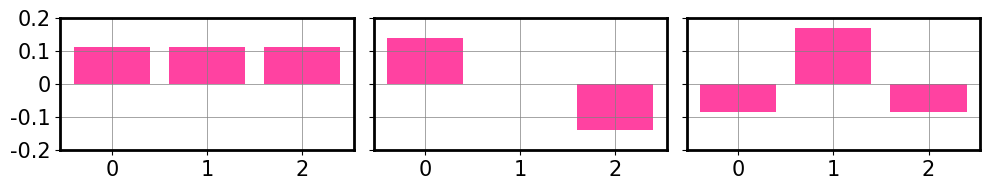

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=N, figsize=(10, 2), dpi=100)  # Adjusted figsize and dpi

# Loop through each mode and plot
for i in range(N):  # Single row for modes 0 to N-1
    ion_numbers = np.arange(0, N)  # Ion indices
    ax = axes[i]  # Get the current axis

    # Plot the eta values for the current mode
    ax.bar(ion_numbers, etas_radial[i], color='#FF42A1')  # Use etas_radial[i] directly for bar heights
    ax.set_ylim(-0.2, 0.2)  # Adjust y-axis limits as needed

    # Set x-ticks for every ion
    ax.set_xticks(ion_numbers)  # Show every ion number
    ax.set_xticklabels(ion_numbers, fontsize=15)  # Set larger font size for x-tick labels

    # Set y-ticks for all plots but only show labels for the leftmost plot
    ax.set_yticks([-0.2, -0.1, 0, 0.1, 0.2])  # Set specific y-tick positions
    if i == 0:
        ax.set_yticklabels([-0.2, -0.1, 0, 0.1, 0.2], fontsize=15)  # Show y-tick labels for the leftmost plot
    else:
        ax.set_yticklabels([])  # Hide y-tick labels for other plots

    # Set thicker axes lines
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    # Add gridlines
    ax.grid(True, which='both', axis='both', color='gray', linestyle='-', linewidth=0.5)

    # Set tick labels fontsize
    ax.tick_params(axis='both', which='major', labelsize=15)  # Increased tick mark font size

# Use tight layout to adjust spacing
fig.tight_layout()

plt.show()

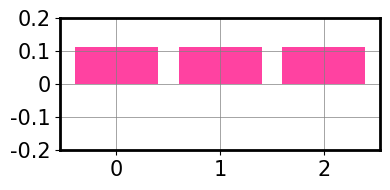

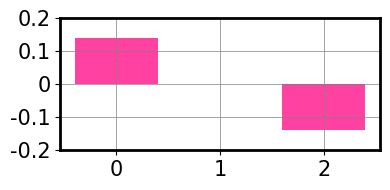

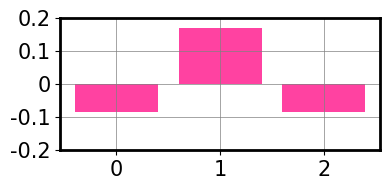

In [6]:
for i in range(N):  # Loop through each mode
    ion_numbers = np.arange(0, N)  # Ion indices

    # Create a new figure for each mode
    fig, ax = plt.subplots(figsize=(10/2.5, 2), dpi=100)  # Adjust figsize and dpi as needed

    # Plot the eta values for the current mode
    ax.bar(ion_numbers, etas_radial[i], color='#FF42A1')  # Use etas_radial[i] directly for bar heights
    ax.set_ylim(-0.2, 0.2)  # Adjust y-axis limits as needed

    # Set x-ticks for every ion
    ax.set_xticks(ion_numbers)  # Show every ion number
    ax.set_xticklabels(ion_numbers, fontsize=15)  # Set font size for x-tick labels

    # Set y-ticks
    ax.set_yticks([-0.2, -0.1, 0, 0.1, 0.2])  # Set specific y-tick positions
    ax.set_yticklabels([-0.2, -0.1, 0, 0.1, 0.2], fontsize=15)  # Set font size for y-tick labels

    # Set thicker axes lines
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    # Add gridlines
    ax.grid(True, which='both', axis='both', color='gray', linestyle='-', linewidth=0.5)


    # Use tight layout to adjust spacing
    fig.tight_layout()

    # Show the plot
    plt.show()

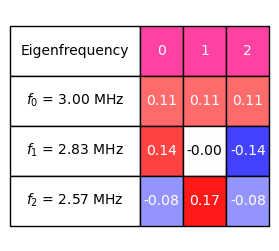

In [7]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')

maximum = max(max(etas_radial))
min = -1*maximum

# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=min-0.05, vmax=maximum+0.05)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

# Show the plot
plt.show()

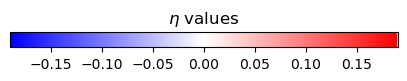

In [8]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# 8 circles equally spaced in a line

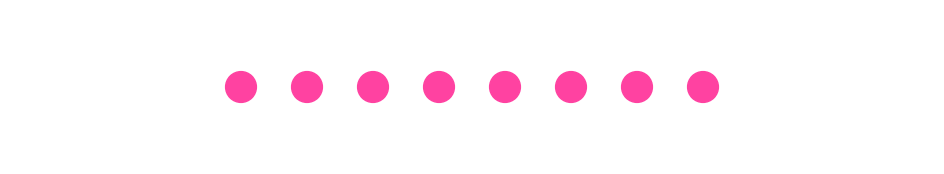

In [12]:
# Number of circles
num_circles = 8

# Circle parameters
radius = 0.1  # Radius of each circle
spacing = 0.5  # Spacing between circles
y_position = 0  # Fixed y-coordinate for all circles

# Calculate the x-coordinates for the circles
x_coords = np.linspace(-1.5, 1.5, num_circles)  # Equally spaced x-coordinates

# Create the plot
fig, ax = plt.subplots(figsize=(20, 2))

# Plot the circles
for x in x_coords:
    circle = plt.Circle((x, y_position), radius, color='#FF42A1', zorder=2)  # Circle with fixed radius
    ax.add_artist(circle)

# Set equal aspect ratio
ax.set_aspect('equal')

# Set limits for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 0.5)

# Remove axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()

# 9 circles in a line

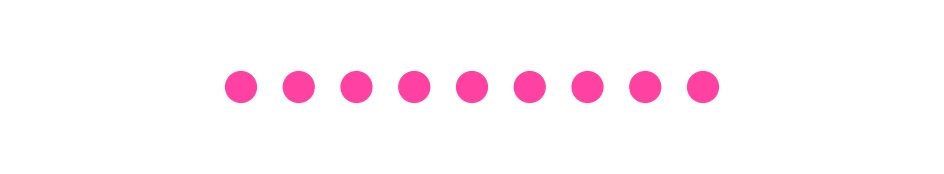

In [13]:
# Number of circles
num_circles = 9

# Circle parameters
radius = 0.1  # Radius of each circle
spacing = 0.5  # Spacing between circles
y_position = 0  # Fixed y-coordinate for all circles

# Calculate the x-coordinates for the circles
x_coords = np.linspace(-1.5, 1.5, num_circles)  # Equally spaced x-coordinates

# Create the plot
fig, ax = plt.subplots(figsize=(20, 2))

# Plot the circles
for x in x_coords:
    circle = plt.Circle((x, y_position), radius, color='#FF42A1', zorder=2)  # Circle with fixed radius
    #middle = plt.Circle((x_coords[tweezed_ions[0]], y_position), radius, color="green", zorder=2)
    ax.add_artist(circle)
    #ax.add_artist(middle)
    
# Set equal aspect ratio
ax.set_aspect('equal')

# Set limits for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 0.5)

# Remove axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()

# modes for 8 ions, no tweeezers yet

In [115]:
N = 30
tweezed_ions = []
w_rf_a = 2*pi*0.03*1e6
w_rf_r = 2*pi*3e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

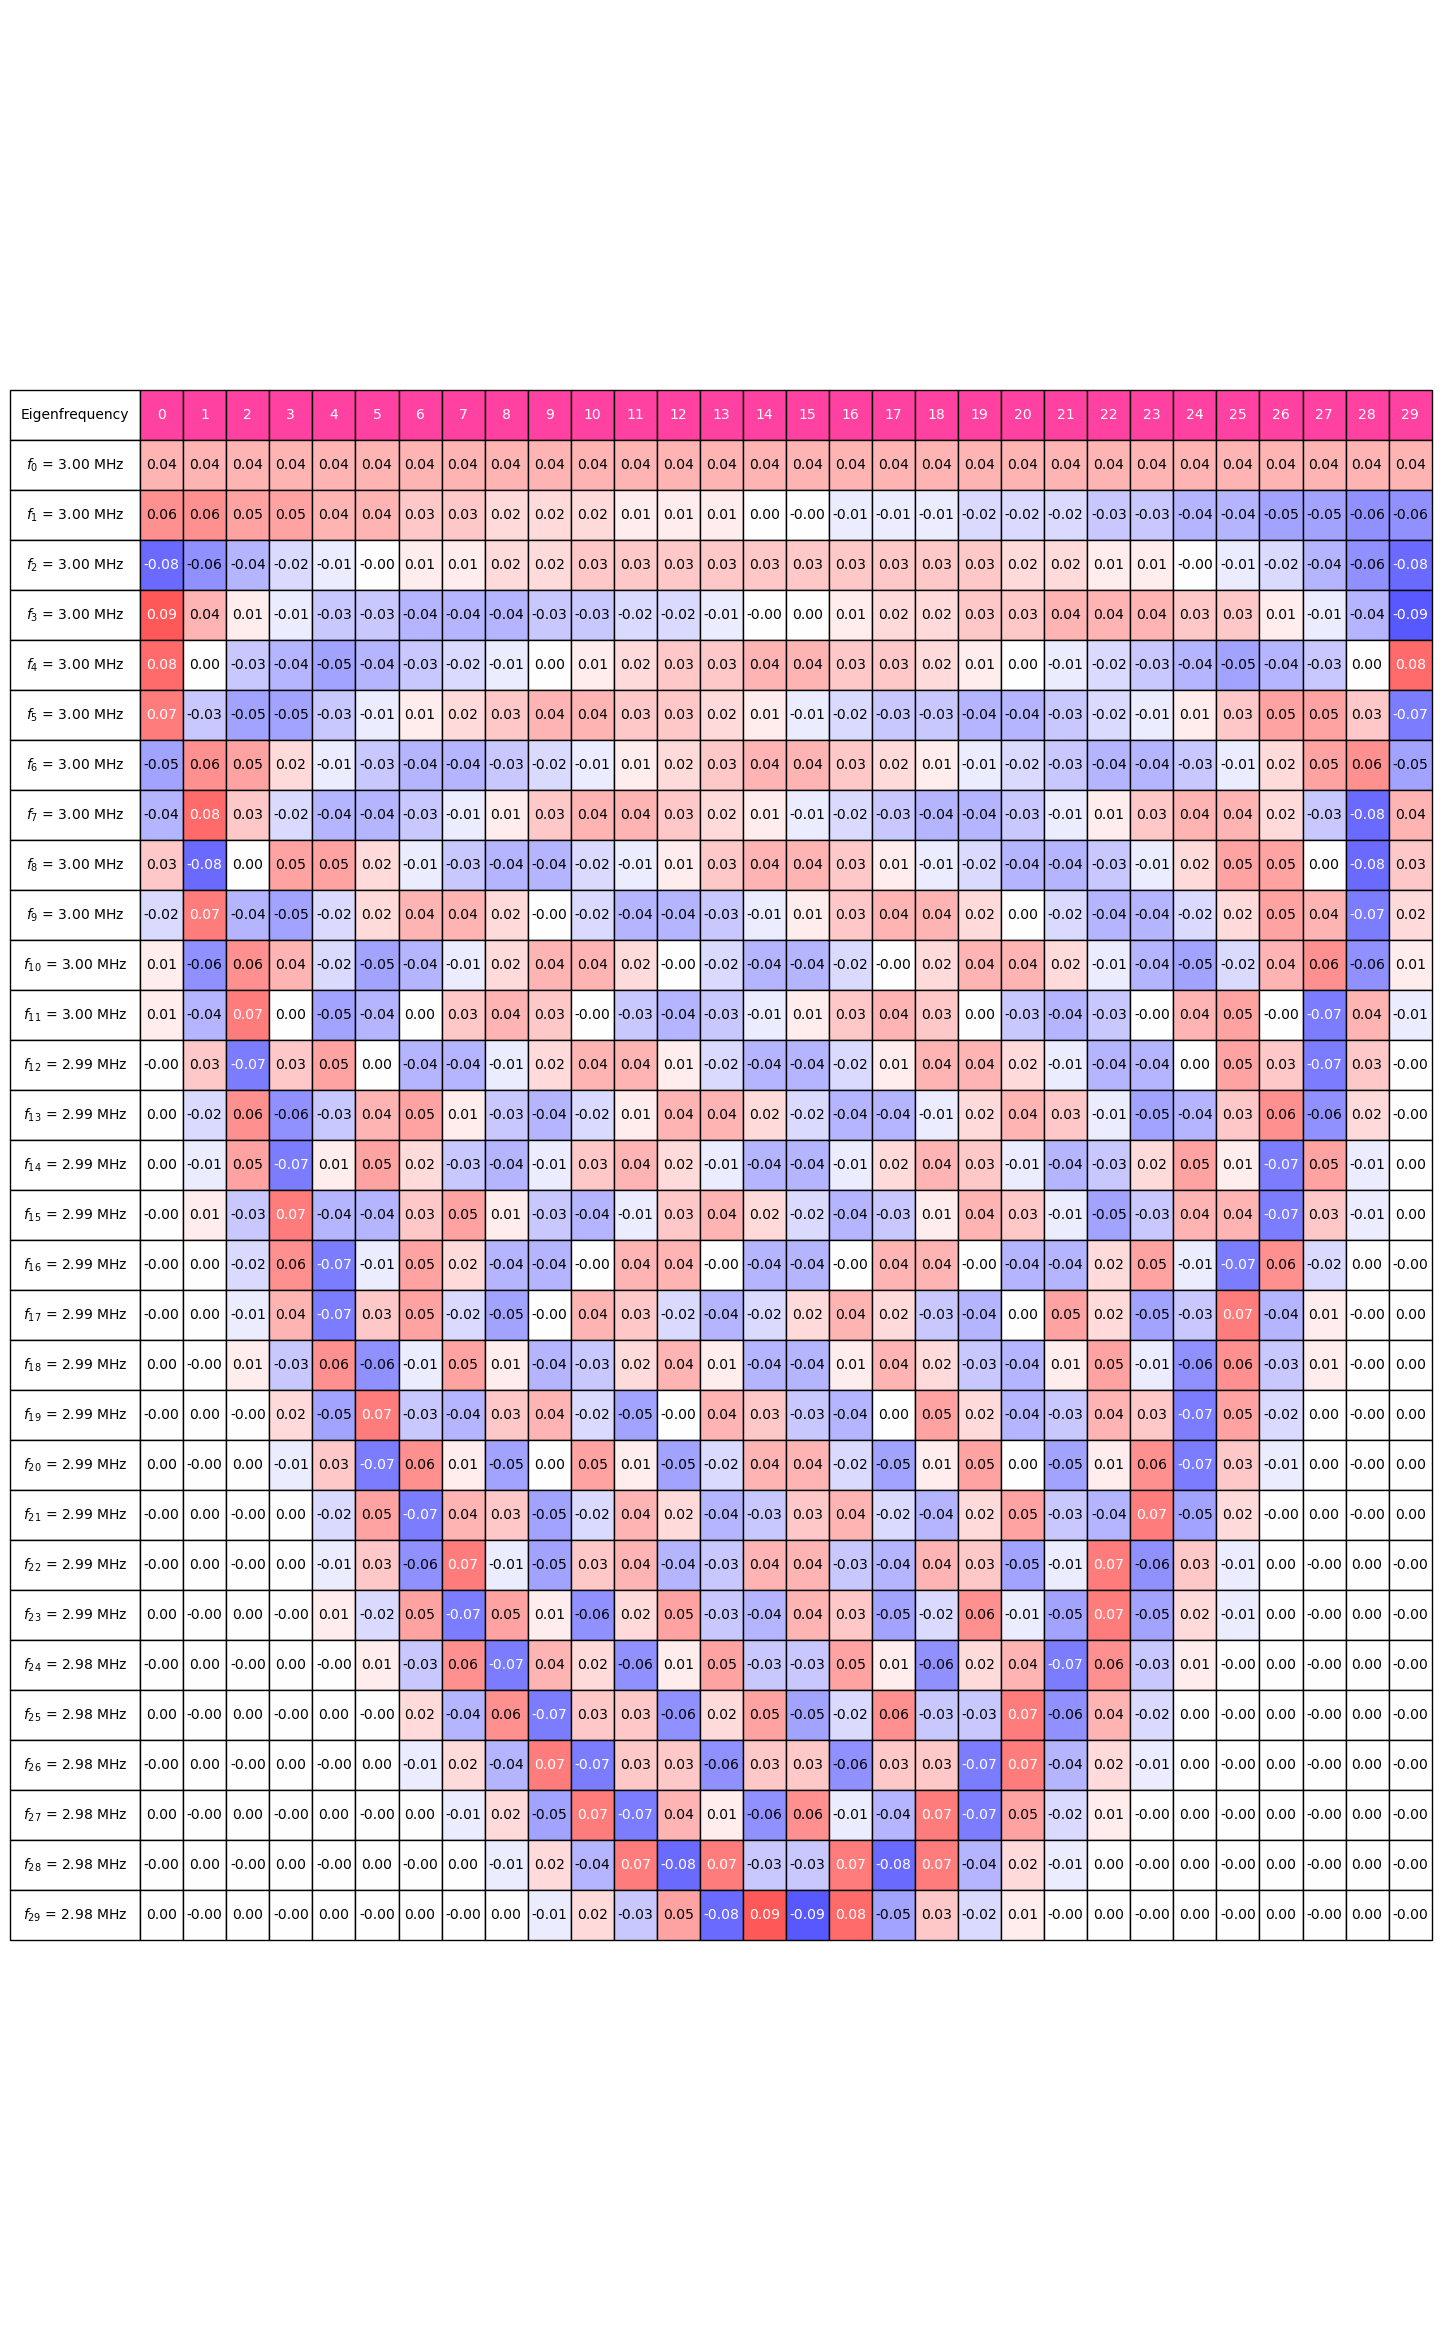

In [116]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')
maximum = max(max(etas_radial))
min = -1*maximum
# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=min-0.05, vmax=maximum+0.05)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

# Show the plot
plt.show()

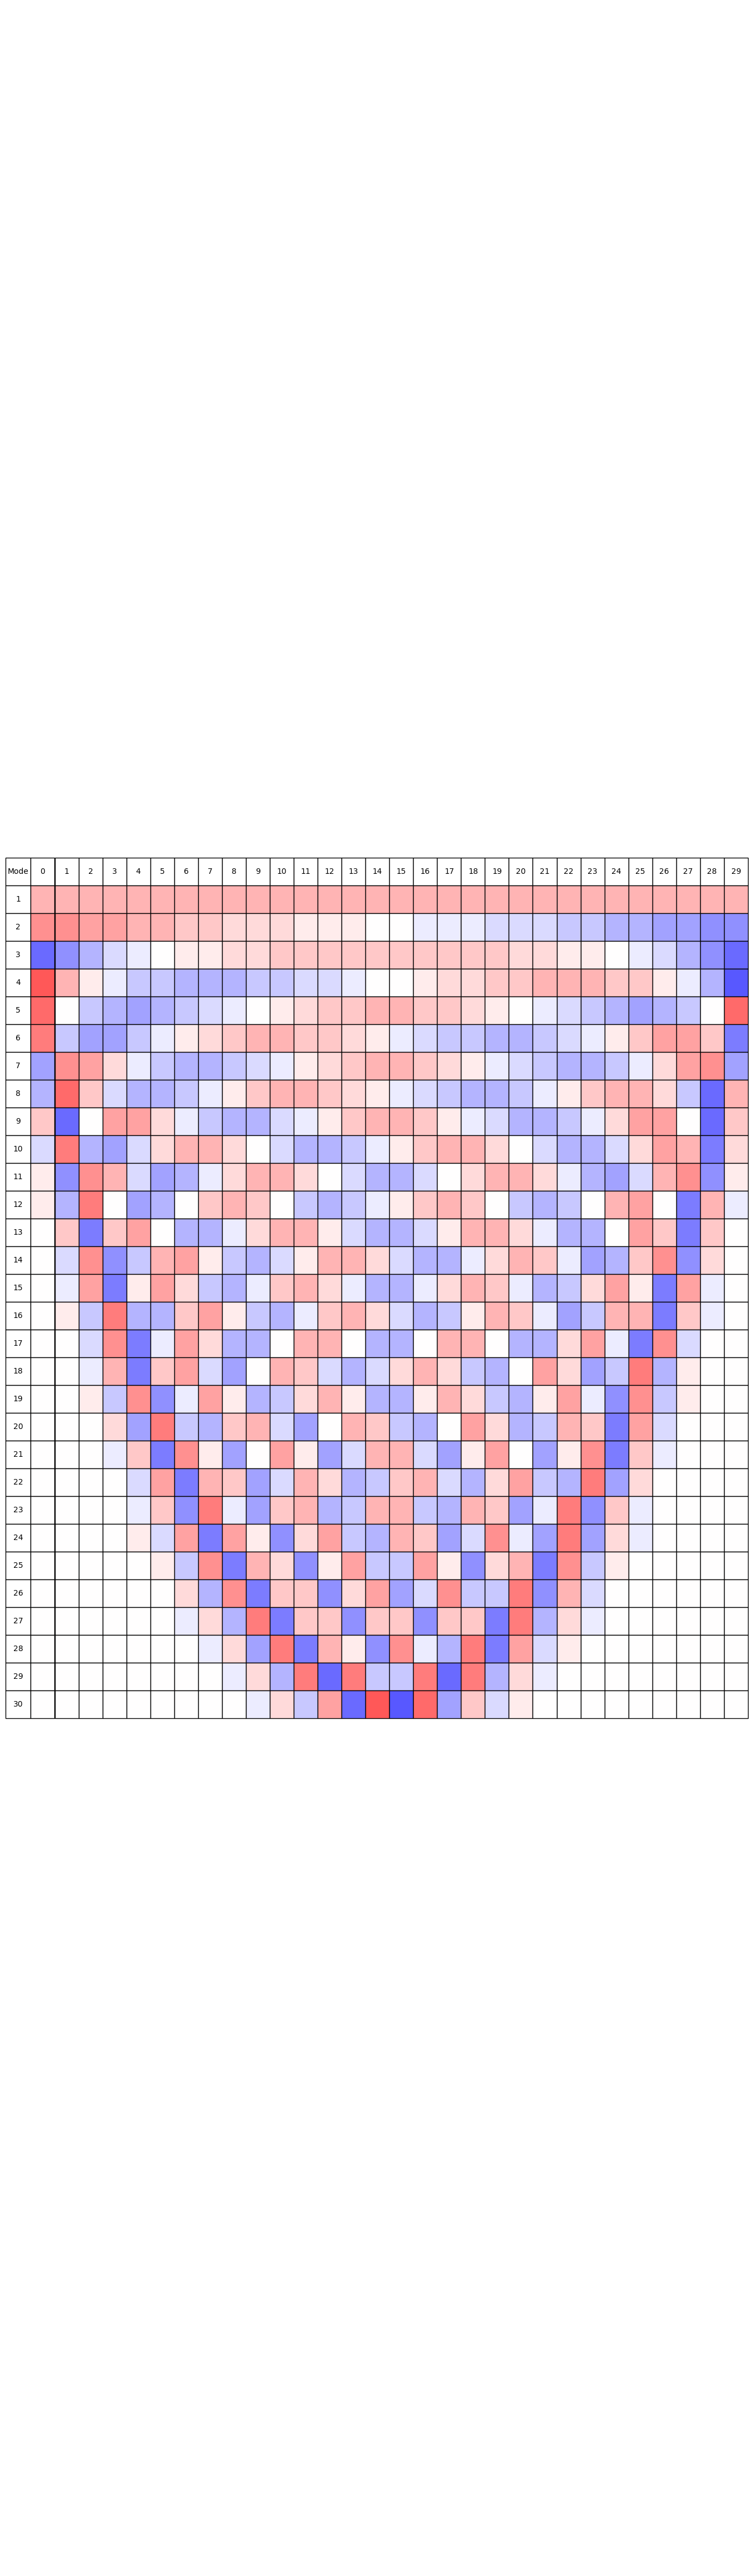

In [117]:
fig, ax = plt.subplots(figsize=(0.25, 2 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')
maximum = max(max(etas_radial))
min = -1*maximum
# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_radial[index]]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Set column labels from 0 through 29 (assuming 30 ions/modes)
column_labels = ['Mode'] + [str(i) for i in range(30)]

table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
colWidths = [0.3] * (len(column_labels))
colWidths[0] = 0.3
table.auto_set_column_width(col=[i for i in range(len(colWidths))])
table.scale(1, 3)

cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=min-0.05, vmax=maximum+0.05)

# Applying color to the value cells, and set font color to the same as the background
for i, row in enumerate(table_data, start=1):
    # Set the first column entry [i,0] to display i (row number)
    table[i, 0].get_text().set_text(str(i))
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color=color)
        table[0, i].set_text_props(color='black')

# Set white background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):
    table[0, j].set_facecolor("white")
table[0, 0].set_facecolor('white')

plt.show()

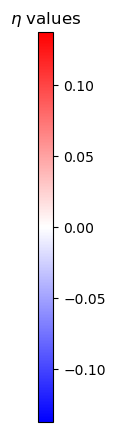

In [118]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(0.2,5))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='vertical')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

In [120]:
# Plot each mode frequency as a vertical line at its mode number

# Extract omega values (make sure each value is a different height)
omega_values = np.array([mode[0] for mode in radial_modes])
print(omega_values)

[3000000.         2999849.99624981 2999634.49350907 2999361.00478707
 2999034.92258457 2998660.08830758 2998239.30458943 2997774.70177492
 2997267.97098595 2996720.50404989 2996133.47747132 2995507.90509756
 2994844.67327884 2994144.56571609 2993408.28178113 2992636.45044465
 2991829.64111468 2990988.37222438 2990113.1181414  2989204.31479471
 2988262.36432904 2987287.63897331 2986280.48431325 2985241.2220493
 2984170.15237568 2983067.55600397 2981933.69594972 2980768.81905269
 2979573.15734408 2978346.9292255 ]


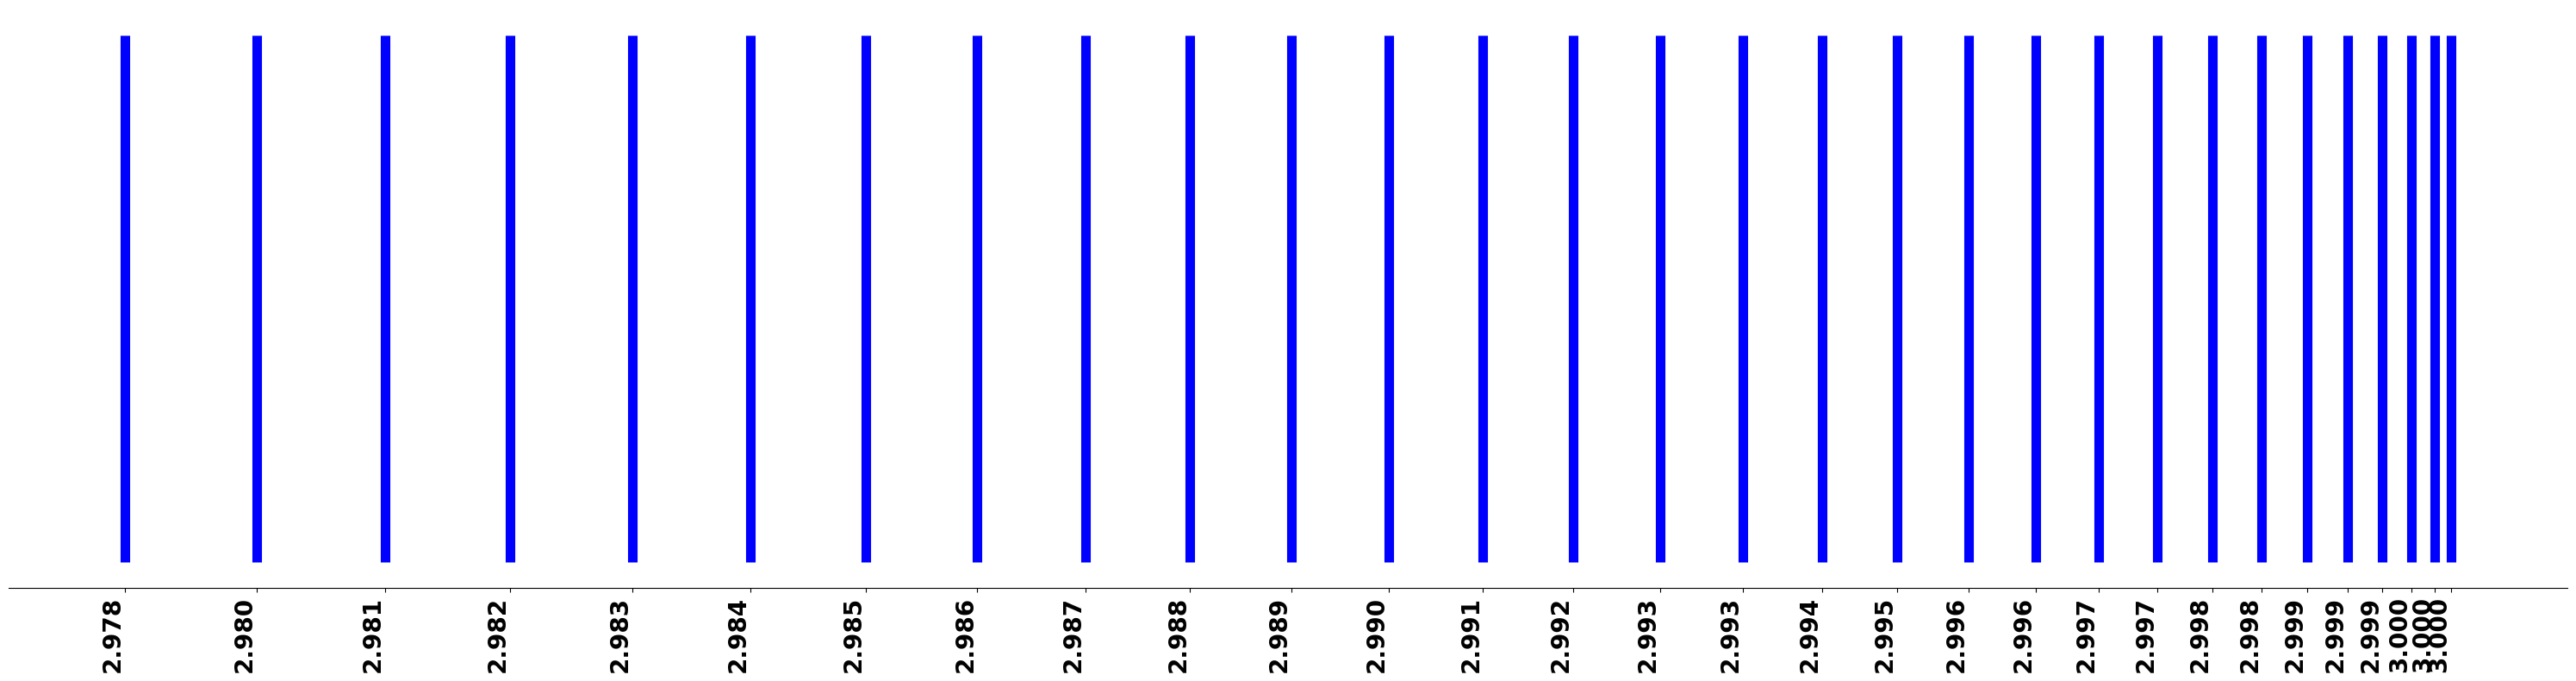

In [149]:
# Plot each mode frequency as a vertical line at its frequency (MHz), with x-labels at 3 decimal points, tilted, no y-axis, no top line

omega_values = np.array([mode[0] for mode in radial_modes])
freq_values_mhz = omega_values / 1e6  # Convert omega (rad/s) to frequency (MHz)

fig, ax = plt.subplots(figsize=(30, 8))
line_height = 1  # All lines have the same height

for freq in freq_values_mhz:
    ax.vlines(freq, 0, line_height, color='b', linewidth=8)

#ax.set_xlabel('Mode Frequency (MHz)', fontsize=20)
#ax.set_title('Mode Frequencies')
ax.set_xticks(freq_values_mhz)
ax.set_xticklabels([f"{x:.3f}" for x in freq_values_mhz], rotation=90, ha='right', fontsize=20, fontweight='bold')  # 3 decimal points

# Hide y-axis and top/right spines
ax.get_yaxis().set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([])

plt.tight_layout()
plt.show()

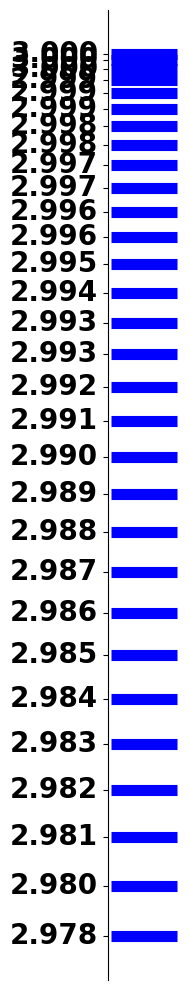

In [154]:
# Plot each mode frequency as a horizontal line at its frequency (MHz), with y-labels at 3 decimal points, tilted, no x-axis, no right line

omega_values = np.array([mode[0] for mode in radial_modes])
freq_values_mhz = omega_values / 1e6  # Convert omega (rad/s) to frequency (MHz)

fig, ax = plt.subplots(figsize=(2, 10))
line_length = 1  # All lines have the same length

for freq in freq_values_mhz:
    ax.hlines(freq, 0, line_length, color='b', linewidth=8)

#ax.set_ylabel('Mode Frequency (MHz)', fontsize=20)
#ax.set_title('Mode Frequencies')
ax.set_yticks(freq_values_mhz)
ax.set_yticklabels([f"{x:.3f}" for x in freq_values_mhz], rotation=0, va='center', fontsize=20, fontweight='bold')  # 3 decimal points

# Hide x-axis and top/right spines
ax.get_xaxis().set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks([])

plt.tight_layout()
plt.show()

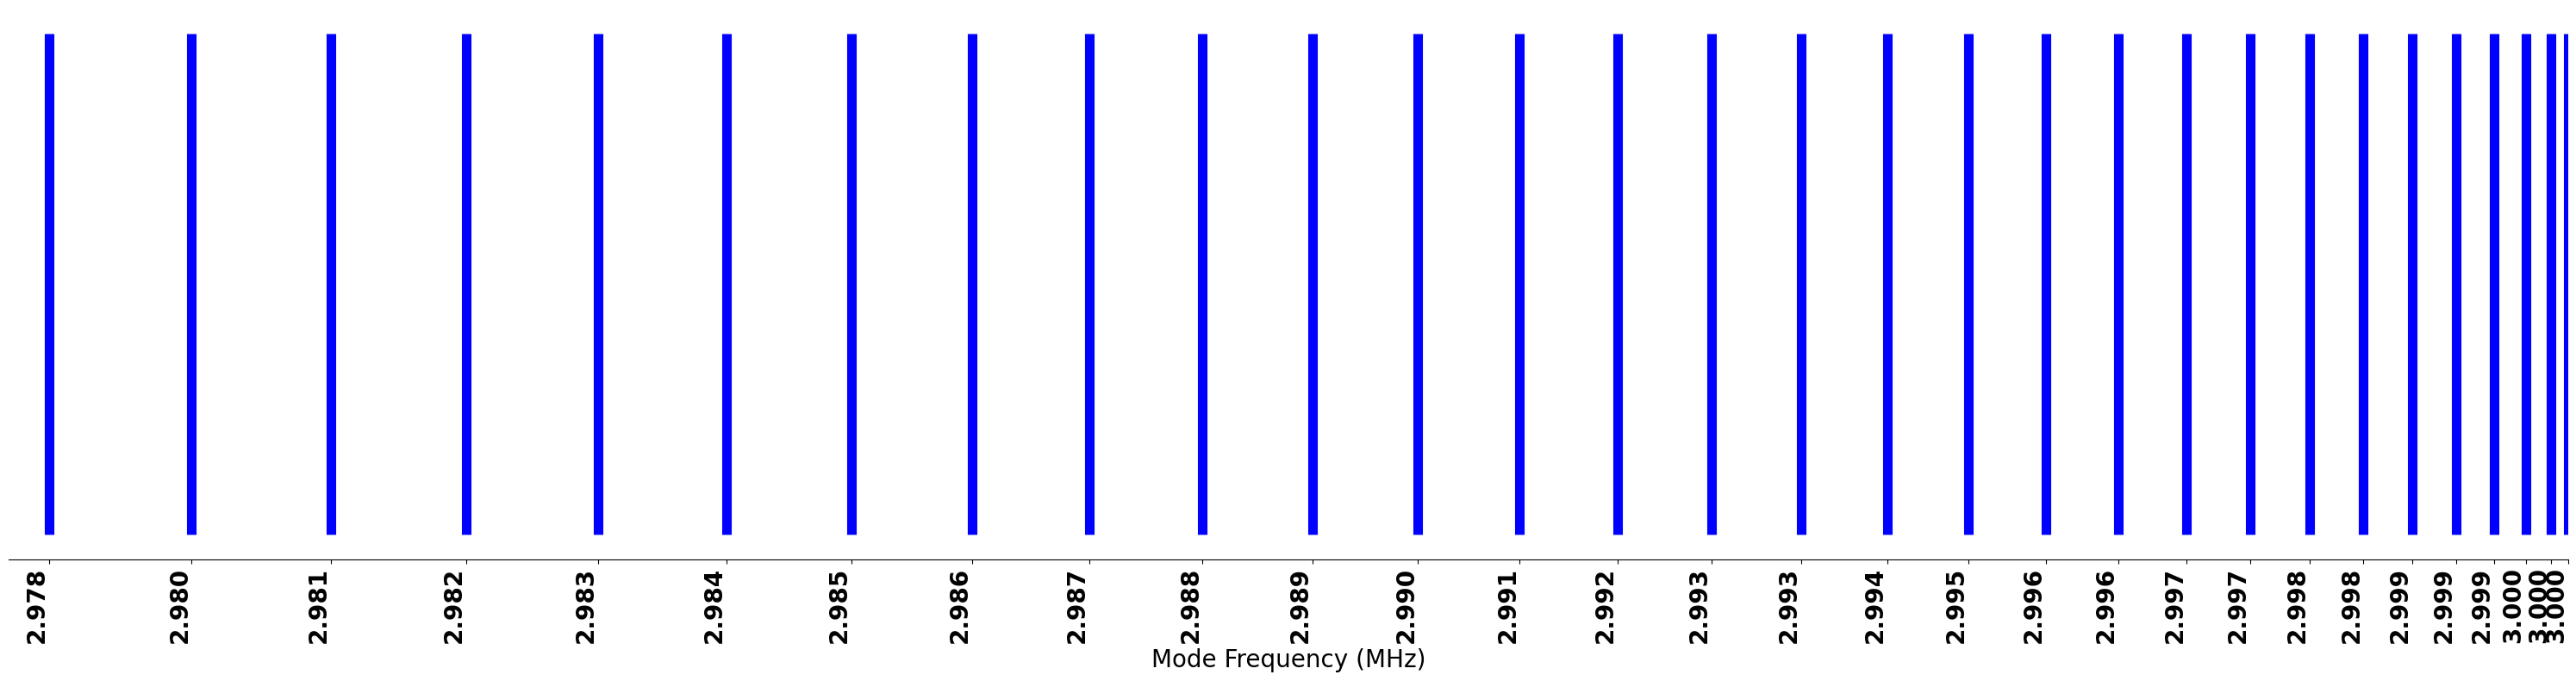

In [180]:
# Plot each mode frequency as a vertical line at its frequency (MHz), with x-axis ticks that correlate to the values

omega_values = np.array([mode[0] for mode in radial_modes])
freq_values_mhz = omega_values / 1e6  # Convert omega (rad/s) to frequency (MHz)

fig, ax = plt.subplots(figsize=(30, 8))
line_height = 1  # All lines have the same height

for freq in freq_values_mhz:
    ax.vlines(freq, 0, line_height, color='b', linewidth=8)

# Set x-axis limits to cover the range of your frequencies
min_freq = np.floor(np.min(freq_values_mhz)*1000)/1000
max_freq = np.ceil(np.max(freq_values_mhz)*1000)/1000
ax.set_xlim(min_freq, max_freq)

# Set x-ticks at the mode frequencies and label them
ax.set_xticks(freq_values_mhz)
ax.set_xticklabels([f"{x:.3f}" for x in freq_values_mhz], rotation=90, ha='right', fontsize=20, fontweight='bold')

# Hide y-axis and top/right spines
ax.get_yaxis().set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([])

ax.set_xlabel('Mode Frequency (MHz)', fontsize=20)

plt.tight_layout()
plt.show()

In [203]:
print(freq_values_mhz)
mode_numbers = np.zeros(len(freq_values_mhz)) 
print(mode_numbers)

[3.         2.99985    2.99963449 2.999361   2.99903492 2.99866009
 2.9982393  2.9977747  2.99726797 2.9967205  2.99613348 2.99550791
 2.99484467 2.99414457 2.99340828 2.99263645 2.99182964 2.99098837
 2.99011312 2.98920431 2.98826236 2.98728764 2.98628048 2.98524122
 2.98417015 2.98306756 2.9819337  2.98076882 2.97957316 2.97834693]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


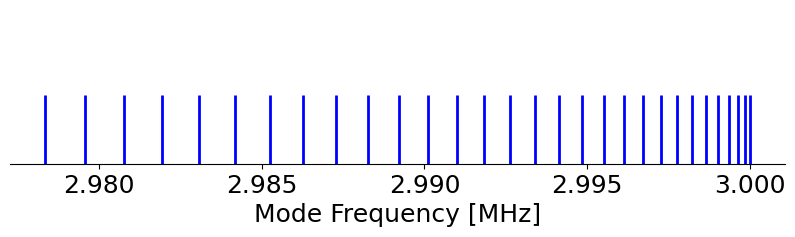

In [217]:
fig, ax = plt.subplots(figsize=(10, 2))
# Make the marker bold by using a thicker line (markeredgewidth) and a darker color
ax.scatter(freq_values_mhz, mode_numbers, marker='|', color='b', s=10000, linewidths=2)
ax.set_ylim(0, 1)  # y-axis starts at 0 (and ends at 1 for visibility)
ax.get_yaxis().set_visible(False)  # Hide y-axis
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([])

# Make x-tick font size larger
ax.tick_params(axis='x', labelsize=18)

# Add x-axis label
ax.set_xlabel('Mode Frequency [MHz]', fontsize=18)

plt.show()

# Potential vs beam waist -- bottom window -- realistic params

In [481]:
lam = 532*1e-9
omegas_twz = 2*pi*c/lam
Popt = 0.5
w0s = np.linspace(0.2,2,100)*1e-6

U = potential(lam,linewidths,omega_res,Popt,w0s)
w_twz_r,w_twz_a = tweezer_optical_potential_to_trap_frequency(lam,linewidths,omega_res,Popt,w0s,m,U)
s = scattering(omega_tweezer,linewidths,omega_res,Popt,w0s)

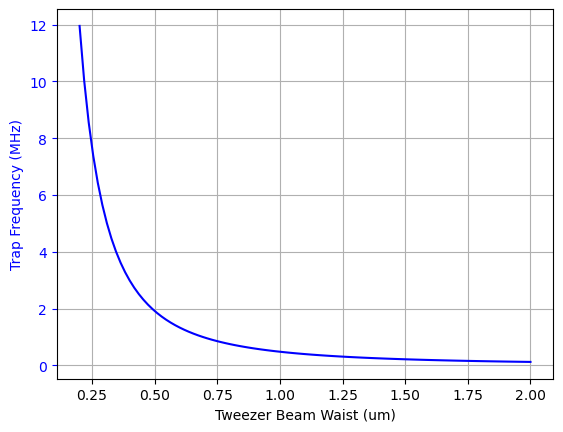

In [485]:
fig,ax = plt.subplots(1,1,dpi=100)

ax.plot(w0s*1e6,w_twz_r*1e-6/(2*np.pi),'b')

#ax2=ax.twinx()
#ax2.plot(w0s*1e6,s/(2*pi),'r')

#ax.set_ylim(0,500)
#ax2.set_ylim(0,12)

ax.set_xlabel('Tweezer Beam Waist (um)')
ax.set_ylabel('Trap Frequency (MHz)',color='b')
#ax2.set_ylabel('Scattering Rate (Hz)',color='r')

ax.tick_params(axis='y', colors='b')
#ax2.tick_params(axis='y', colors='r')

ax.grid()
#plt.savefig("BeamWaist_Sweep_Freq_Scatter.png")
plt.show() 

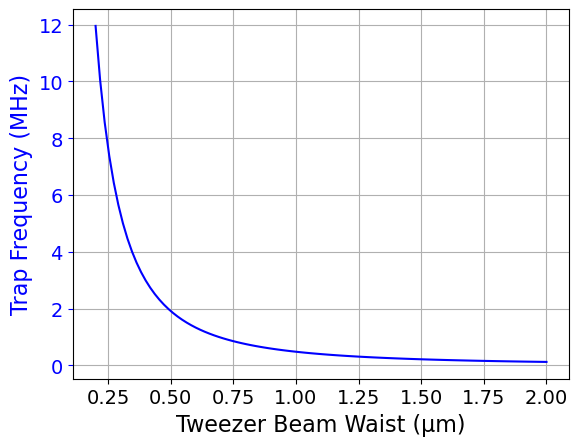

In [486]:
fig, ax = plt.subplots(1, 1, dpi=100)

# Plot trap frequency
ax.plot(w0s * 1e6, w_twz_r * 1e-6 / (2 * np.pi), 'b')

# Add secondary y-axis for scattering rate
#ax2 = ax.twinx()
#ax2.plot(w0s * 1e6, s / (2 * np.pi), 'r')

# Set axis labels with larger font size
ax.set_xlabel('Tweezer Beam Waist (µm)', fontsize=16)
ax.set_ylabel('Trap Frequency (MHz)', color='b', fontsize=16)
#ax2.set_ylabel('Scattering Rate (Hz)', color='r', fontsize=16)

# Increase tick label font size
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14, colors='b')
#ax2.tick_params(axis='y', labelsize=14, colors='r')

# Add grid
ax.grid()

# Save and show the plot
plt.show()

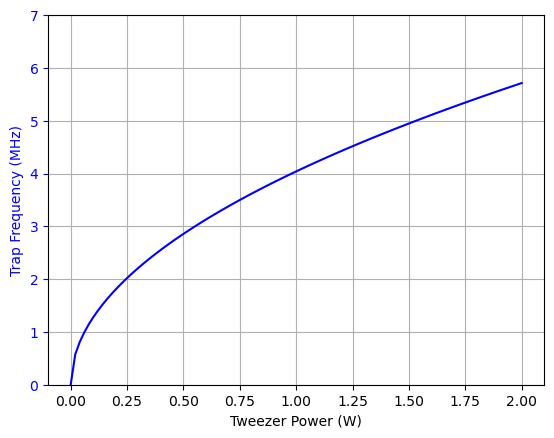

In [487]:
lam = 532*1e-9
omegas_twz = 2*pi*c/lam
Popts = np.linspace(0,2,100)
w0 = 0.5e-6

U = potential(omegas_twz,linewidths,omega_res,Popts,w0)
w_twz_r,w_twz_a = tweezer_optical_potential_to_trap_frequency(lam,linewidths,omega_res,Popts,w0,m,U)
s = scattering(omegas_twz,linewidths,omega_res,Popts,w0)
fig,ax = plt.subplots(1,1,dpi=100)

ax.plot(Popts,w_twz_r*1e-6/(2*np.pi),'b')

#ax2=ax.twinx()
#ax2.plot(Popts,s/(2*pi),'r')

ax.set_ylim(0,7)
#ax2.set_ylim(0,200)

ax.set_xlabel('Tweezer Power (W)')
ax.set_ylabel('Trap Frequency (MHz)',color='b')
#ax2.set_ylabel('Scattering Rate (Hz)',color='r')

ax.tick_params(axis='y', colors='b')
#ax2.tick_params(axis='y', colors='r')

ax.grid()
plt.savefig("Power_Sweep_Freq_Scatter.png")
plt.show()

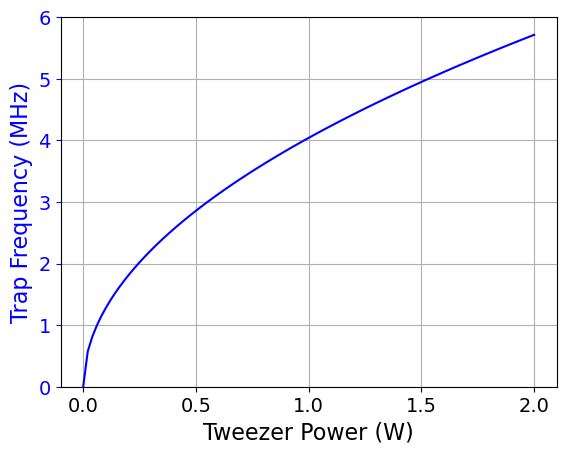

In [488]:
fig, ax = plt.subplots(1, 1, dpi=100)

# Plot trap frequency
ax.plot(Popts, w_twz_r * 1e-6 / (2 * np.pi), 'b')

# Add secondary y-axis for scattering rate
#ax2 = ax.twinx()
#ax2.plot(Popts, s / (2 * np.pi), 'r')

# Set y-axis limits
ax.set_ylim(0, 6)
#ax2.set_ylim(0, 175)

# Set axis labels with larger font size
ax.set_xlabel('Tweezer Power (W)', fontsize=16)
ax.set_ylabel('Trap Frequency (MHz)', color='b', fontsize=16)
#ax2.set_ylabel('Scattering Rate (Hz)', color='r', fontsize=16)

# Increase tick label font size
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14, colors='b')
#ax2.tick_params(axis='y', labelsize=14, colors='r')
# Reduce the number of ticks on ax2
#ax2.yaxis.set_major_locator(plt.MaxNLocator(nbins=7))  # Half as many ticks

# Add grid
ax.grid()

# Save and show the plot
#plt.savefig("Power_Sweep_Freq_Scatter.png")
plt.show()

# 8 ions, high power tweezer in the middle to split the chain into two subchains

In [24]:
N = 9
tweezed_ions = [4]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0.5
w0 = 0.5e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

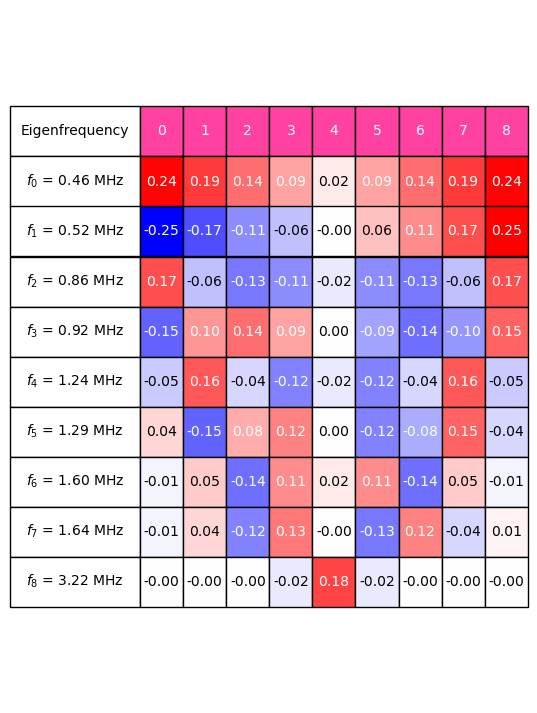

In [25]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black        

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 

# Show the plot
plt.show()

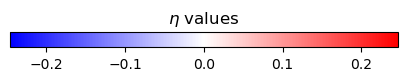

In [ ]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                    
                    
                    
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# Misalignment figs

In [27]:
N = 1
#x = np.empty(N)
omega_rf_axial = 1 * 1 * pi * 1e6
ionspacing = ion_spacing(N,omega_rf_axial)
P0 = 1
beam_waist = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P0,beam_waist)
omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer,linewidths,omega_res,P0,beam_waist,m,U)[0]
#print(omega_tw_radial)
tweezed_ion = 0
displacement = beam_waist * 0.9

tweeze_on = fsolve(pot_derivative_with_tweeze,ionspacing[0],args = (omega_rf_axial,omega_tw_radial,tweezed_ion,displacement))
print(tweeze_on)
print(ionspacing)
ionspacing[0] == fsolve(pot_derivative_with_tweeze,ionspacing[0],args = (omega_rf_axial,omega_tw_radial,tweezed_ion,displacement))

(tweeze_on[0] - ionspacing[0][tweezed_ion])*1e9

[7.22812074e-07]
[array([0.]), []]


722.8120739390333

[-6.67934432e-25  1.33515109e-12] [[ 7.56683955e-65 -2.01406819e-49]
 [-2.01406819e-49  9.65977710e-34]]


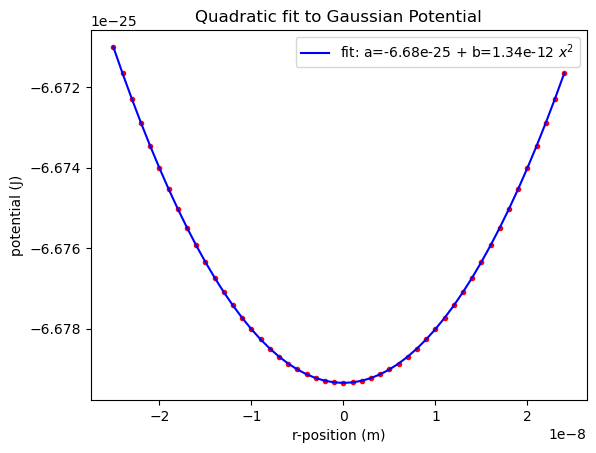

In [28]:
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0,z_pos, lambda_beam)

#making a list of positions to pass through the potential function.  This is in the frame of the laser beam,
#so 0 is the center of the beam
x_pos = np.arange((1/2)*-0.05*1e-6,(1/2)*(0.05)*1e-6,0.001e-6)
y_pos = 0


intens = intensity(x_pos,y_pos,P0, wz)
a =  potential_position_dependent(omega_res,linewidths,omega_tweezer,intens)                      
#fitting the potential vector to a quadratic function
from scipy import optimize

def quadratic(x,a,b):
    return a+b*(x**2)
xdata = x_pos
ydata = a

popt, pcov = curve_fit(quadratic, xdata, ydata)

print(popt,pcov)

plt.plot(xdata,ydata,'r.')
plt.plot(xdata,quadratic(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (m)")
plt.ylabel("potential (J)")
plt.title("Quadratic fit to Gaussian Potential")
plt.legend()
plt.show()

1.0
[-6.67934432e-25  1.33515109e-12] [[ 7.56683955e-65 -2.01406819e-49]
 [-2.01406819e-49  9.65977710e-34]]


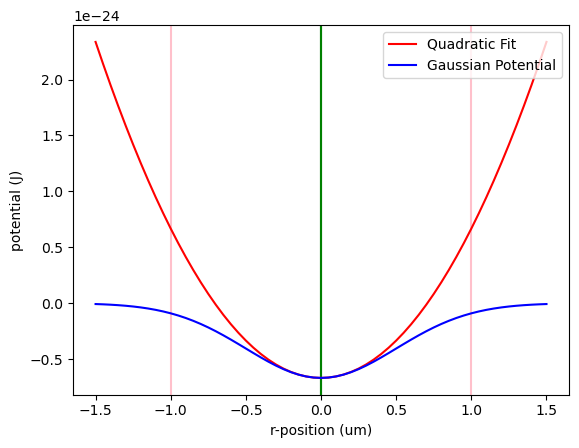

In [29]:
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0,z_pos, lambda_beam)
x_pos = np.arange((-1.5)*1e-6,(1.5)*1e-6,0.05e-6)
dial_values = np.arange(0, 1.1, 0.05)
print(dial_values[20])
y_pos = x_pos
y_pos = 0
intens = intensity(x_pos,y_pos,P0, wz)
intens_0 = intensity(0,0,P0,wz)
popt, pcov = curve_fit(quadratic, xdata, ydata)

print(popt,pcov)

a =  potential_position_dependent(omega_res,linewidths,omega_tweezer,intens)  
plt.axvline(x=(w0 ) * (dial_values[0] + dial_values[00] * 0.025)*1e6, color='g', linestyle='-')   
plt.axvline(x=(w0 ) * (dial_values[00] - dial_values[00] * 0.025)*1e6, color='g', linestyle='-') 
plt.axvline(x = w0*1e6,color = 'pink')
plt.axvline(x = -w0*1e6,color = 'pink') 
plt.xlabel("r-position (um)")
plt.ylabel("potential (J)") 
plt.plot(x_pos*1e6,quadratic(x_pos, *popt) ,'r-',label="Quadratic Fit")
plt.plot(x_pos*1e6,a,'b-',label = "Gaussian Potential")
plt.legend(loc = 'upper right')
plt.savefig("Gaussian_Potential_Quad_Fit.png")
plt.show()

11
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[-1.e-08  0.e+00  1.e-08]
[9.750e-08 1.000e-07 1.025e-07]
[1.95e-07 2.00e-07 2.05e-07]
[2.925e-07 3.000e-07 3.075e-07]
[3.9e-07 4.0e-07 4.1e-07]
[4.875e-07 5.000e-07 5.125e-07]
[5.85e-07 6.00e-07 6.15e-07]
[6.825e-07 7.000e-07 7.175e-07]
[7.8e-07 8.0e-07 8.2e-07]
[8.775e-07 9.000e-07 9.225e-07]
[9.750e-07 1.000e-06 1.025e-06]


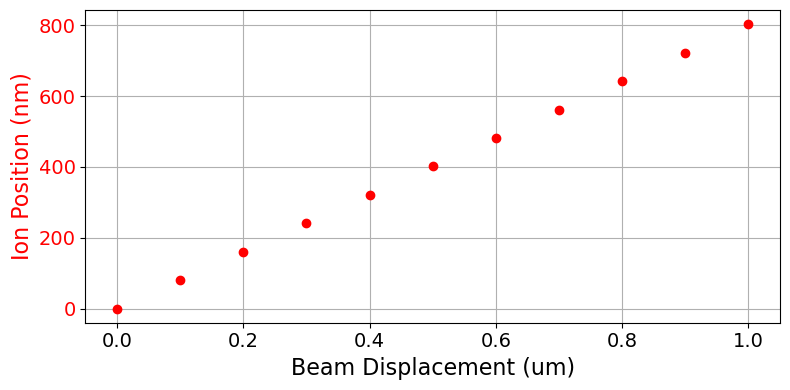

Fit-Based Radial Frequencies: [1.0098199044354967, 0.9998148106201019, 0.9702458068880687, 0.9228977124324411, 0.8604727519680189, 0.786385456861247, 0.7044538208939404, 0.6185760015343877, 0.5324302565447281, 0.44922923984920893, 0.37154917515484165]
Ion Positions (nm): [  0.          80.31245266 160.62490532 240.93735798 321.24981064
 401.5622633  481.87471596 562.18716862 642.49962128 722.81207394
 803.1245266 ]


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, fsolve

# Constants
#dial_values = np.arange(0, 1.1, 0.05)
dial_values = np.arange(0,1.1,0.1) #for testing
print(len(dial_values))
print(dial_values)
results = []
fits = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []

num_points = 3  # Define the number of points for `r_pos`

for dial in dial_values:
    # Calculate r_pos for each dial value
    if dial == 0:
        r_max = 0.001e-5
        r_min = -0.001e-5
    else:
        r_max = (w0 ) * (dial + dial * 0.025)
        r_min = (w0 ) * (dial - dial * 0.025)
    r_pos = np.linspace(r_min, r_max, num_points)
    print(r_pos)
    r_pos_save.append(r_pos)
    x_pos = r_pos
    y_pos = 0

    # Calculate ydata based on r_pos
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

    # Directly use r_pos and ydata for fitting (assuming they always match in length)
    xdata = r_pos
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))

    # Store the fit and its error
    fits.append(fit*1e-6/(2*pi)) # making sure the fit is kHz, and is regular frequency not angular frequency 
    errors.append(fit_error*1e-6)

    # Displacement and ion position
    displacement = w0 * dial
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])

# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm

# Plotting
fig, ax = plt.subplots(figsize=(8, 4))


ax.set_xlabel('Beam Displacement (um)',fontsize = '16')

ax.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')
#ax2.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')

# Plot ion position on the right y-axis
#ax2 = ax1.twinx()
ax.plot(dial_values*w0*1e6, positions, 'o', color='red', label='Ion Equliubrium Position')
ax.set_ylabel('Ion Position (nm)', color='red',fontsize = '16')
ax.tick_params(axis='y', labelcolor='red',labelsize = '14')

# Add title and grid
#fig.suptitle('Radial Frequency and Ion Position vs Tweezer Misalignment')
ax.grid(True)
fig.tight_layout()

# Save and show the plot
#plt.savefig("Frequency_Position_Misalignment.png")
plt.show()

print("Fit-Based Radial Frequencies:", fits)
print("Ion Positions (nm):", positions)

[6.424996212791408e-07]
[6.424996212791408e-07, 6.437544674725836e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07, 6.497402583136637e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07, 6.497402583136637e-07, 6.508827989823924e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07, 6.497402583136637e-07, 6.508827

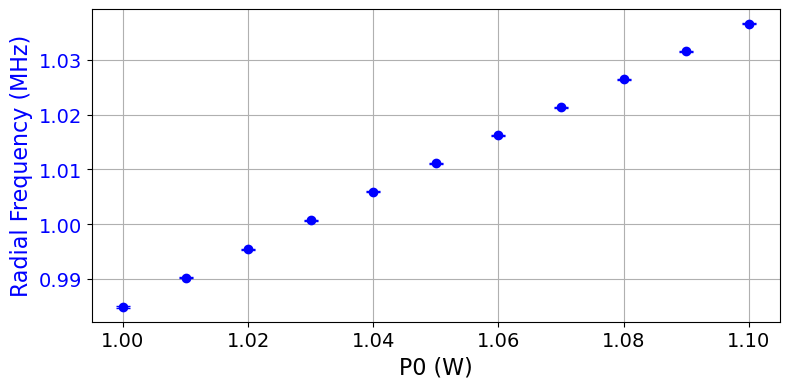

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Constants
P0_values = np.linspace(1, 1.1, 11)  # P0 values ranging from 1 W to 2 W
dial = 0.8  # Fixed dial value
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []
P0_analytical = 1  # Fixed P0 for analytical frequency calculation
results = []
frequencies = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
num_points = 1000  # Fixed number of points for each P0 value

# Calculate the analytical frequency only once using P0_analytical
U = potential(omega_tweezer, linewidths, omega_res, P0_analytical, w0)
analytical = tweezer_optical_potential_to_trap_frequency(lambda_beam, linewidths, omega_res, P0_analytical, w0, m, U)

for P0 in P0_values:
    # Displacement and ion position
    displacement = w0 * dial
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])
    print(positions)
    # Define r_pos for the current P0 value
    r_max = (w0 ) * (dial + dial * 0.025) - tweeze_on[0]
    r_min = (w0) * (dial - dial * 0.025) - tweeze_on[0]
    r_pos = np.linspace(r_min, r_max, num_points)

    # Recalculate ydata for each P0 value
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(r_pos, 0, P0, wz))

    # Use r_pos and ydata for fitting
    xdata = r_pos

    # Perform the fit for the potential
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))



    # Store the fit frequency and its error
    frequencies.append(fit * 1e-6 / (2 * np.pi))  # Convert to MHz
    errors.append(fit_error * 1e-6 / (2 * np.pi))  # Convert to MHz


# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm
# Plotting
fig, ax = plt.subplots(figsize=(8, 4))
ax.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')
ax.tick_params(axis='y', labelcolor='blue',labelsize = '14')

# Plot fit-based radial frequency on the left y-axis
ax.errorbar(P0_values, frequencies, yerr=errors, fmt='o', label='Fit-Based Frequency', color='blue', capsize=5)
ax.set_xlabel('P0 (W)',fontsize = '16')
ax.set_ylabel('Radial Frequency (MHz)', color='blue',fontsize = '16')
ax.tick_params(axis='y', labelcolor='blue')

# Plot ion position on the right y-axis
#ax2 = ax1.twinx()
#ax2.plot(P0_values, positions, 'o', color='red', label='Ion Position')
#ax2.set_ylabel('Ion Position (nm)', color='red')
#ax2.tick_params(axis='y', labelcolor='red')
#ax2.set_ylim(0, 500) # want this y-axis to match the other one 

# Add title and grid
ax.grid(True)
fig.tight_layout()
plt.show()

11
0.0
0.1
0.2
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8
0.9
1.0


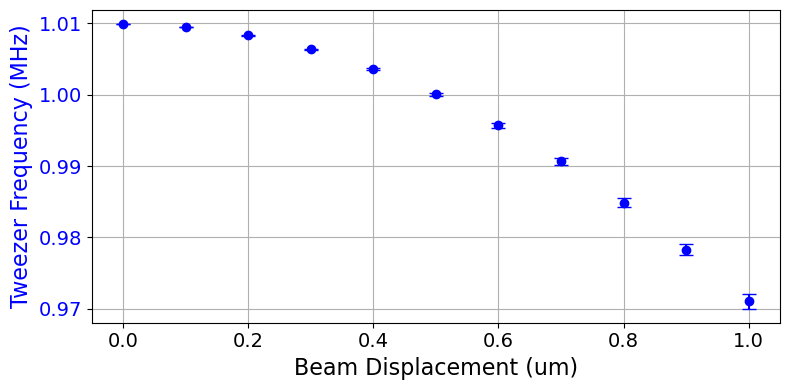

Fit-Based Radial Frequencies: [1.0098270306769954, 1.0094744144395653, 1.0082874250844451, 1.006312288473327, 1.003553759677684, 1.00001846798193, 0.9957148902123153, 0.9906533160475862, 0.9848458059600603, 0.9783061422207691, 0.9710497730067458]
Ion Positions (nm): [  0.          80.31245266 160.62490532 240.93735798 321.24981064
 401.5622633  481.87471596 562.18716862 642.49962128 722.81207394
 803.1245266 ]


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, fsolve

# Constants
dial_values = np.arange(0, 1.1, 0.05)
dial_values = np.arange(0,1.1,0.1) #for testing
print(len(dial_values))
results = []
fits = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []

num_points = 1000  # Define the number of points for `r_pos`

for dial in dial_values:
    # Displacement and ion position
    displacement = w0 * dial
    print(dial)
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])
    # Calculate r_pos for each dial value
    if dial == 0:
        r_max = 0.001e-5 - tweeze_on[0]
        r_min = -0.001e-5- tweeze_on[0]
    else:
        r_max = (w0 ) * (dial + dial * 0.025)- tweeze_on[0]
        r_min = (w0 ) * (dial - dial * 0.025)- tweeze_on[0]
    r_pos = np.linspace(r_min, r_max, num_points)
    r_pos_save.append(r_pos)
    #print(r_pos)
    x_pos = r_pos
    y_pos = 0
     # Calculate ydata based on new r_pos
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

    # Directly use r_pos and ydata for fitting (assuming they always match in length)
    xdata = r_pos
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))

    # Store the fit and its error
    fits.append(fit*1e-6/(2*pi)) # making sure the fit is kHz, and is regular frequency not angular frequency 
    errors.append(fit_error*1e-6)

# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm

# Plotting
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot fit-based radial frequency on the left y-axis
ax1.errorbar(dial_values*w0*1e6, fits, yerr=errors, fmt='o', label='Fit-Based Radial Frequency', color='blue', capsize=5)
ax1.set_xlabel('Beam Displacement (um)', fontsize=16)
ax1.set_ylabel('Tweezer Frequency (MHz)', color='blue', fontsize=16)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=14)
#ax1.set_ylim(30,80)
ax1.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')

"""
# Plot ion position on the right y-axis
ax2 = ax1.twinx()
ax2.plot(dial_values, positions, 'o', color='red', label='Ion Position')
ax2.set_ylabel('Ion Position (nm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
"""
# Add title and grid
#fig.suptitle('Radial Frequency and Ion Position vs Tweezer Misalignment')
ax1.grid(True)
fig.tight_layout()

# Save and show the plot
#plt.savefig("Frequency_Position_Misalignment.png")
plt.show()

print("Fit-Based Radial Frequencies:", fits)
print("Ion Positions (nm):", positions)

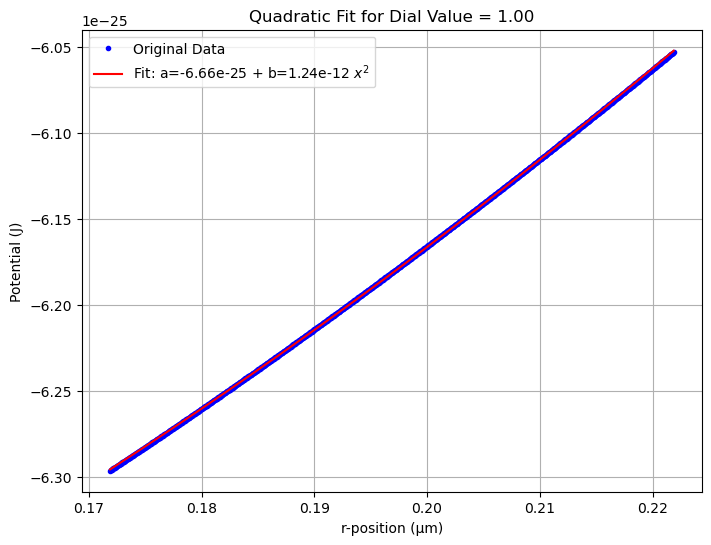

0.9710497730067457


In [33]:
# Select a specific dial value to plot (e.g., dial = 0.5)
dial_index = 10  # Index of the desired dial value (adjust as needed)
selected_dial = dial_values[dial_index]

# Extract the corresponding r_pos and ydata
r_pos_selected = r_pos_save[dial_index]
x_pos = r_pos_selected
y_pos = 0

# Recalculate ydata for the selected dial value
ydata_selected = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

# Perform the quadratic fit for the selected dial value
popt, pcov = curve_fit(quadratic, r_pos_selected, ydata_selected)

# Generate the fitted curve
fitted_curve = quadratic(r_pos_selected, *popt)

# Plot the original data and the fit
plt.figure(figsize=(8, 6))
plt.plot(r_pos_selected * 1e6, ydata_selected, 'b.', label='Original Data')  # Convert r_pos to µm for plotting
plt.plot(r_pos_selected * 1e6, fitted_curve, 'r-', label=f'Fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("r-position (µm)")
plt.ylabel("Potential (J)")
plt.title(f"Quadratic Fit for Dial Value = {selected_dial:.2f}")
plt.legend()
plt.grid(True)
plt.savefig(f"Quadratic_Fit_Dial_{selected_dial:.2f}.png")  # Save the plot
plt.show()
f_fit = (np.sqrt(2*popt[1]/m)/(2*pi)) * 1e-6
print(f_fit)

[6.424996212791408e-07]
[6.424996212791408e-07, 6.474018344575854e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07, 6.679518811790632e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07, 6.679518811790632e-07, 6.714151274496745e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07, 6.679518811790632e-07, 6.

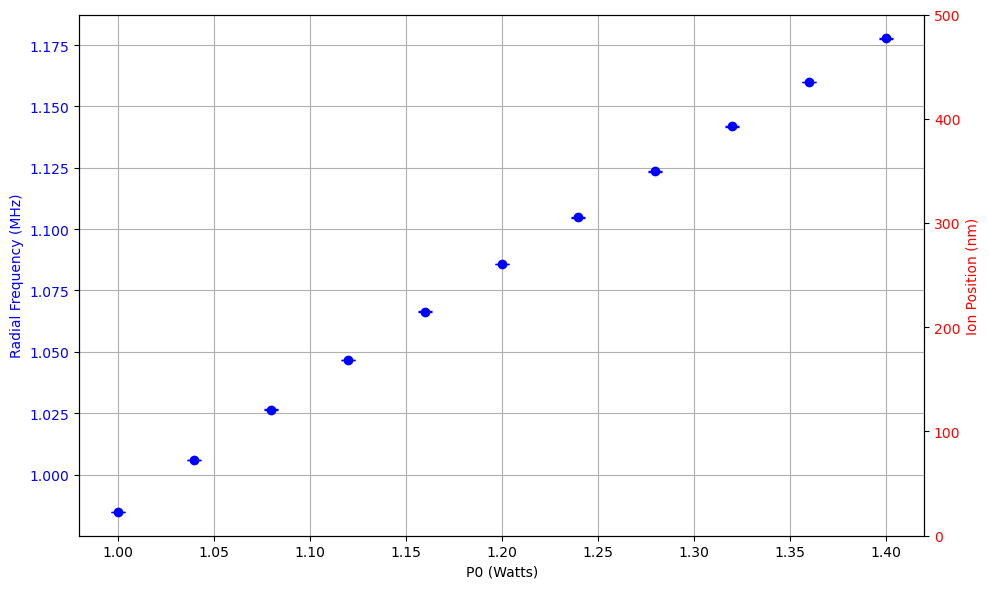

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Constants
P0_values = np.linspace(1, 1.4, 11)  # P0 values ranging from 1 W to 2 W
dial = 0.8  # Fixed dial value
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []
P0_analytical = 1  # Fixed P0 for analytical frequency calculation
results = []
frequencies = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
num_points = 1000  # Fixed number of points for each P0 value

# Calculate the analytical frequency only once using P0_analytical
U = potential(omega_tweezer, linewidths, omega_res, P0_analytical, w0)
analytical = tweezer_optical_potential_to_trap_frequency(lambda_beam, linewidths, omega_res, P0_analytical, w0, m, U)

for P0 in P0_values:
    # Displacement and ion position
    displacement = w0 * dial
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])
    print(positions)
    # Define r_pos for the current P0 value
    r_max = (w0 ) * (dial + dial * 0.025) - tweeze_on[0]
    r_min = (w0) * (dial - dial * 0.025) - tweeze_on[0]
    r_pos = np.linspace(r_min, r_max, num_points)

    # Recalculate ydata for each P0 value
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(r_pos, 0, P0, wz))

    # Use r_pos and ydata for fitting
    xdata = r_pos

    # Perform the fit for the potential
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))



    # Store the fit frequency and its error
    frequencies.append(fit * 1e-6 / (2 * np.pi))  # Convert to MHz
    errors.append(fit_error * 1e-6 / (2 * np.pi))  # Convert to MHz


# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot fit-based radial frequency on the left y-axis
ax1.errorbar(P0_values, frequencies, yerr=errors, fmt='o', label='Fit-Based Frequency', color='blue', capsize=5)
ax1.set_xlabel('P0 (Watts)')
ax1.set_ylabel('Radial Frequency (MHz)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot ion position on the right y-axis
ax2 = ax1.twinx()
ax2.plot(P0_values, positions, 'o', color='red', label='Ion Position')
ax2.set_ylabel('Ion Position (nm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 500) # want this y-axis to match the other one 

# Add title and grid
ax1.grid(True)
fig.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Select a specific dial value to plot (e.g., dial = 0.5)
dial_index = 0  # Index of the desired dial value (adjust as needed)
selected_dial = dial_values[dial_index]

# Extract the corresponding r_pos and ydata
r_pos_selected = r_pos_save[dial_index]
x_pos = r_pos_selected
y_pos = 0

# Recalculate ydata for the selected dial value
ydata_selected = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

# Perform the quadratic fit for the selected dial value
popt, pcov = curve_fit(quadratic, r_pos_selected, ydata_selected)

# Generate the fitted curve for the zoomed-in range
fitted_curve = quadratic(r_pos_selected, *popt)

# Plot the original data and the fit (zoomed-in plot)
plt.figure(figsize=(8, 6))
plt.plot(r_pos_selected * 1e6, ydata_selected, 'b.', label='Original Data')  # Convert r_pos to µm for plotting
plt.plot(r_pos_selected * 1e6, fitted_curve, 'r-', label=f'Fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("r-position (µm)")
plt.ylabel("Potential (J)")
plt.title(f"Quadratic Fit for Dial Value = {selected_dial:.2f}")
plt.legend()
plt.grid(True)
plt.show()

# Generate a new range for the zoomed-out plot
r_pos_zoomed_out = np.linspace(-1.5e-6, 1.5e-6, num_points)  # Range from -1.5 µm to 1.5 µm
ydata_zoomed_out = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(r_pos_zoomed_out, 0, P0, wz))
fitted_curve_zoomed_out = quadratic(r_pos_zoomed_out, *popt)

# Plot the zoomed-out version
plt.figure(figsize=(8, 6))
plt.plot(r_pos_zoomed_out * 1e6, ydata_zoomed_out, 'b-', label='Potential (Gaussian)')  # Convert r_pos to µm for plotting
plt.plot(r_pos_zoomed_out * 1e6, fitted_curve_zoomed_out, 'r--', label=f'Quadratic Fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("r-position (µm)")
plt.ylabel("Potential (J)")
plt.title(f"Zoomed-Out Quadratic Fit for Dial Value = {selected_dial:.2f}")
plt.legend()
plt.grid(True)

# Set zoomed-out limits to match the range of r_pos_zoomed_out
plt.xlim(-1.5, 1.5)  # Set x-axis limits to match the zoomed-out range (in µm)
plt.ylim(min(ydata_zoomed_out) * 1.1, max(ydata_zoomed_out) * 1.1)  # Adjust y-axis limits to show more space
plt.savefig(f"Zoomed_Out_Quadratic_Fit_Dial_{selected_dial:.2f}.png")  # Save the zoomed-out plot
plt.show()

# Calculate and print the fit-based frequency
f_fit = (np.sqrt(2 * popt[1] / m) / (2 * np.pi)) * 1e-6
print(f_fit)

IndexError: list index out of range

# One tweezer but weaker power

In [ ]:
N = 9
tweezed_ions = [4]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 100e-3
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
w_tw_a = omega_tweezer_a(U,beam_waist,tweezer_wavelength,m)
omeg_tweezer_a = np.zeros(N)
omeg_tweezer_a[tweezed_ions] = w_tw_a
omeg_rf_r = w_rf_r * np.ones(N)
omega_combined_ra = np.sqrt(omeg_rf_r**2 + omeg_tweezer_a**2)

ra_modes = mode_calc_r(m,omega_combined_ra,ueq,N)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

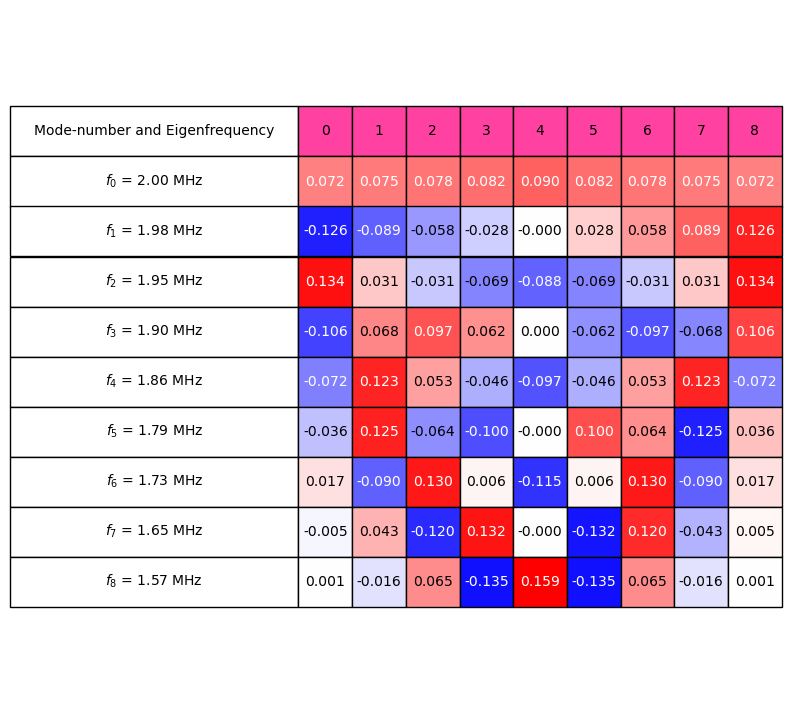

In [ ]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.3f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Mode-number and Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_radial))-0.01, vmax=max(max(etas_radial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 

# Show the plot
plt.show()

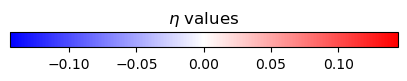

In [ ]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# one tweezer, but tweezer axial and trap radial

In [45]:
N = 9
tweezed_ions = [4]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 100e-3
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
w_tw_a = omega_tweezer_a(U,beam_waist,tweezer_wavelength,m)
w_tw_r = omega_tweezer_r(U,beam_waist,m)
print(U)
print((w_tw_a/(2*pi))*1e-6)
print((w_tw_r/(2*pi))*1e-6)

omeg_tweezer_a = np.zeros(N)
omeg_tweezer_a[tweezed_ions] = w_tw_a
omeg_rf_r = w_rf_r * np.ones(N)
omega_combined_ra = np.sqrt(omeg_rf_r**2 + omeg_tweezer_a**2)

ra_modes = mode_calc_r(m,omega_combined_ra,ueq,N)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)
etas_ra = eta(ra_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
data_ra = {
    "Frequency (Hz)": [entry[0] for entry in ra_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]
for i in range(len(etas_ra[0])):  # Iterate over the number of components in each mode vector
    data_ra[f"Component {i+1}"] = [eta[i] for eta in etas_ra]
    

-6.679344769692264e-26
0.03823951742236945
0.3193490592467196


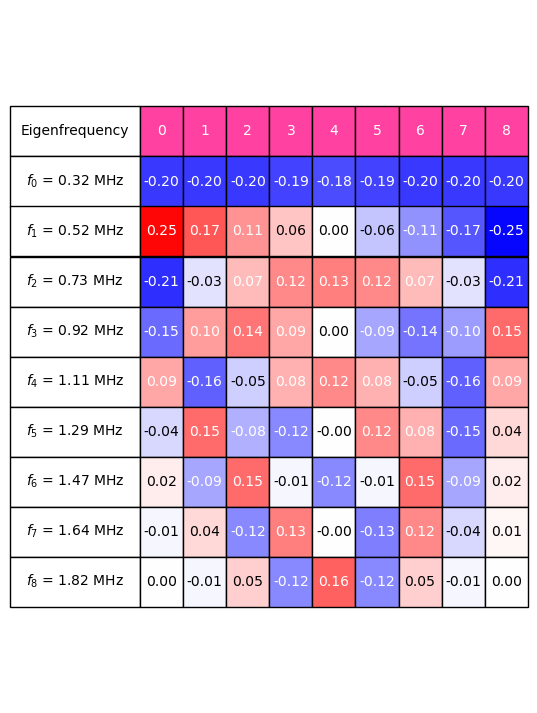

In [49]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black     

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 

# Show the plot
plt.show()

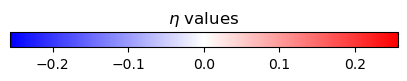

In [50]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# frequency scan for 422


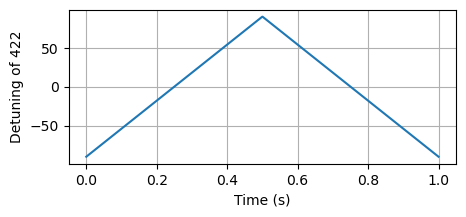

In [ ]:
from scipy.signal import sawtooth
import numpy as np
import matplotlib.pyplot as plt

# Parameters
frequency = 1  # Frequency in Hz
amplitude = 90  # Amplitude
time = np.linspace(0, 1, 1000)  # Time vector for 1 second

# Generate the symmetric sawtooth wave (up and down with equal slope)
y = amplitude * sawtooth(2 * np.pi * frequency * time, width=0.5)

# Plot the sawtooth wave
plt.figure(figsize=(5, 2))
plt.plot(time, y)
#plt.title("Symmetric Sawtooth Wave")
plt.xlabel("Time (s)")
plt.ylabel("Detuning of 422")
plt.grid(True)
plt.show()

# messing around with "idea" tweezers

In [17]:
N = 9
tweezed_ions = [0,2,4,6,8]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0.2
w0 = 0.5e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

[0, 2, 4, 6, 8]


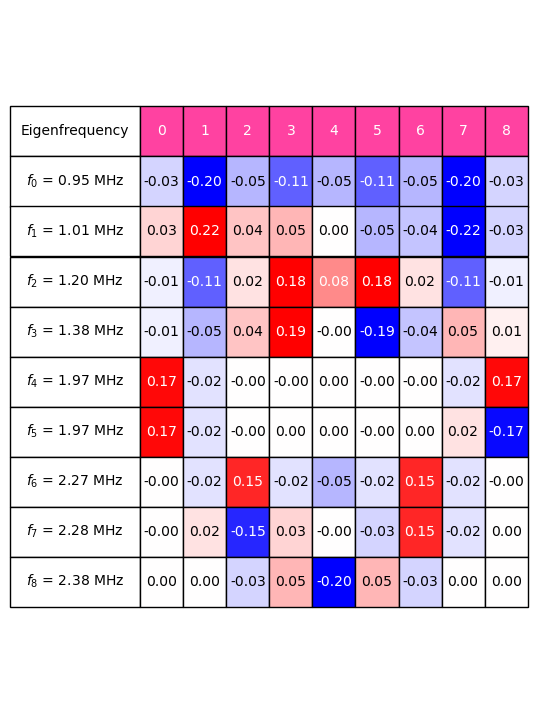

In [18]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black        

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 
print(tweezed_ions)
# Show the plot
plt.show()

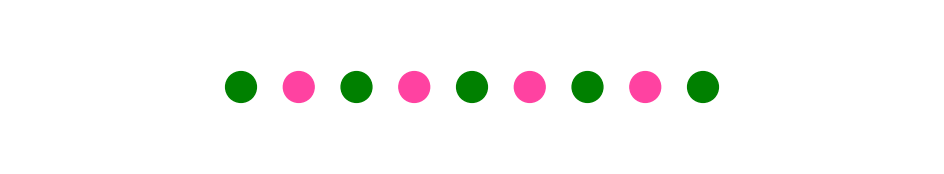

In [7]:
# Number of circles
num_circles = 9

# Circle parameters
radius = 0.1  # Radius of each circle
spacing = 0.5  # Spacing between circles
y_position = 0  # Fixed y-coordinate for all circles

# Calculate the x-coordinates for the circles
x_coords = np.linspace(-1.5, 1.5, num_circles)  # Equally spaced x-coordinates

# Indices of circles to be green
green_indices = [0, 2, 4, 6, 8]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 2))

# Plot the circles
for i, x in enumerate(x_coords):
    color = "green" if i in green_indices else "#FF42A1"  # Green for specified indices, pink otherwise
    circle = plt.Circle((x, y_position), radius, color=color, zorder=2)  # Circle with fixed radius
    ax.add_artist(circle)
    
# Set equal aspect ratio
ax.set_aspect('equal')

# Set limits for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 0.5)

# Remove axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()

# validating some things from mode_structure_changes

In [5]:
P_opt = 3
N = 3
tweezed_ions = [0]
w_rf_r =1* 1e6*2*pi
w_rf_a = w_rf_r / 3
omega_rf_axial = w_rf_a 
w0 =1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
ueq = ion_spacing(N, w_rf_a)[0]
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

[0]


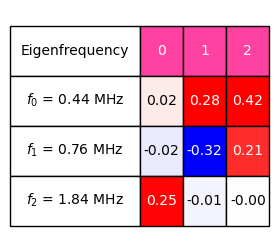

In [6]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black        

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 
print(tweezed_ions)
# Show the plot
plt.show()

# some calculations

In [4]:
linewidth_729 = 1/1.17 * 2*np.pi
rabi_saturation = linewidth_729/2
eta = 0.11
time_sideband = pi/ (2*eta*rabi_saturation)
print(time_sideband)

5.3181818181818175


In [5]:
linewidth_729 = 1/1.17e-6 * 2*np.pi
rabi_saturation = linewidth_729/2
eta = 0.11
time_sideband = pi/ (2*eta*rabi_saturation)
print(time_sideband)

5.318181818181819e-06


In [7]:
(lambdares[0]*hbar*2*pi) / m

3.9278088719359866e-15

In [177]:
N = 10
w_rf_a = 2*pi*1e6
w_rf_r = 2*pi*3e6
ueq = ion_spacing(N, w_rf_a)
print(ueq)

[array([-1.27724224e-05, -9.34312758e-06, -6.45280836e-06, -3.79849817e-06,
       -1.25509111e-06,  1.25509111e-06,  3.79849817e-06,  6.45280836e-06,
        9.34312758e-06,  1.27724224e-05]), [3.429294831034375e-06, 2.890319217900334e-06, 2.654310190936e-06, 2.5434070546652576e-06, 2.510182225975737e-06, 2.543407054664962e-06, 2.6543101909348475e-06, 2.8903192178945877e-06, 3.4292948310827203e-06]]


# fig for DAMOP


In [3]:
# want f_opt on y-axis indicating the trap frequency of the tweezer
#want f_ax_rf on the x-axis indicating the axial rf frequency
n = 1
P0 = 2  # Power in Watts


# minimum theta_bottom is 39.97 degrees
# so minimum w0_bottom = 0.729 um 
w0_array = np.linspace(0.729e-6, 2e-6, 200)  # Range of beam waists from 0.2427 um to 20 um
#print(len(w0_array))
E0_array = np.sqrt(2*P0 / (c*eps0*n*w0_array**2*pi))

tem10_potentials = []
tem10_potentials_y = []
TEM10_y = []
TEM10 = []
# When generating TEM10, also store x_pos for each profile:
TEM10 = []
x_pos_list = []
y_pos_list = []
for i in range(len(w0_array)):
    w0 = w0_array[i]
    E0 = E0_array[i]
    y_pos = 0
    z_pos = 0
    center = w0 / np.sqrt(2)
    x_pos = np.linspace(center - 4*w0, center + 4*w0, 10000)
    wz = beam_propogation(w0, z_pos, tweezer_wavelength)
    intensity_profile = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
    TEM10.append(intensity_profile)
    tem10_potentials.append(potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity_profile))
    x_pos_list.append(x_pos)

for i in range(len(w0_array)):
    w0 = w0_array[i]
    E0 = E0_array[i]
    x_pos = w0 / np.sqrt(2)
    z_pos = 0
    y_pos = np.linspace(-4*w0, 4*w0, 10000)
    wz = beam_propogation(w0, z_pos, tweezer_wavelength)
    intensity_profile_y = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
    TEM10_y.append(intensity_profile_y)
    tem10_potentials_y.append(potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity_profile_y))
    y_pos_list.append(y_pos)
# print("TEM10 Potentials:", tem10_potentials)
# print("TEM10 Intensities:", TEM10)

# plt.figure(figsize=(8, 5))
# y_pos = np.arange(-4*w0_array[0], 4*w0_array[0], 0.0001e-6)
# plt.plot(y_pos * 1e6, TEM10_y[0])
# plt.xlabel('y position (µm)')
# plt.ylabel('Intensity')
# plt.title('TEM10_y[0] Profile')
# plt.grid(True)
# plt.show()

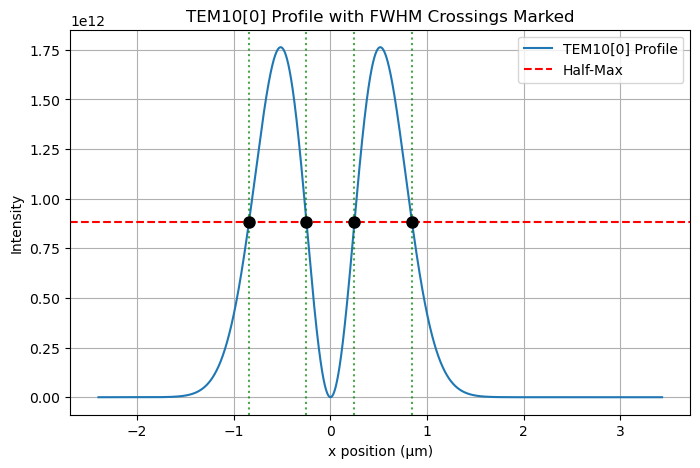

In [4]:
# Now, in your FWHM code, use x_pos_list[i] for each profile:
all_fwhm_indices = []
all_fwhm_xpos_um = []

for i in range(len(TEM10)):
    half_max = np.max(TEM10[i])/2
    signal = TEM10[i] - half_max
    crossings = np.where(np.diff(np.sign(signal)) != 0)[0]
    if len(crossings) >= 4:
        fwhm_indices = [crossings[0], crossings[1], crossings[-2], crossings[-1]]
        fwhm_indices = np.sort(fwhm_indices)
        all_fwhm_indices.append(fwhm_indices.tolist())
        all_fwhm_xpos_um.append((x_pos_list[i][fwhm_indices]*1e6).tolist())
    else:
        all_fwhm_indices.append([])
        all_fwhm_xpos_um.append([])
        print(f"TEM10[{i}] Not enough FWHM crossings found.")

# Plot for the first profile
plt.figure(figsize=(8, 5))
x_pos = x_pos_list[0]
plt.plot(x_pos * 1e6, TEM10[0], label='TEM10[0] Profile')
plt.axhline(np.max(TEM10[0])/2, color='red', linestyle='--', label='Half-Max')
for idx in all_fwhm_indices[0]:
    plt.axvline(x=x_pos[idx]*1e6, color='green', linestyle=':', alpha=0.7)
    plt.plot(x_pos[idx]*1e6, TEM10[0][idx], 'ko', markersize=8)
plt.xlabel('x position (µm)')
plt.ylabel('Intensity')
plt.title('TEM10[0] Profile with FWHM Crossings Marked')
plt.legend()
plt.grid(True)
plt.show()

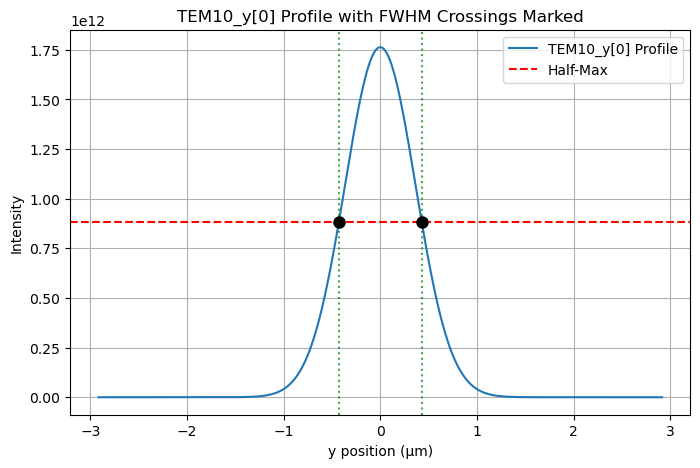

In [5]:
all_fwhm_indices_y = []
all_fwhm_ypos_um_y = []

for i in range(len(TEM10_y)):
    half_max = np.max(TEM10_y[i]) / 2
    signal = TEM10_y[i] - half_max
    crossings = np.where(np.diff(np.sign(signal)) != 0)[0]
    if len(crossings) >= 2:
        # Only take the first and last crossing
        fwhm_indices = [crossings[0], crossings[-1]]
        all_fwhm_indices_y.append(fwhm_indices)
        # Use y_pos_list for y-axis positions
        all_fwhm_ypos_um_y.append((y_pos_list[i][fwhm_indices] * 1e6).tolist())
    else:
        all_fwhm_indices_y.append([])
        all_fwhm_ypos_um_y.append([])
        print(f"TEM10_y[{i}] Not enough FWHM crossings found.")

# Plot for the first profile
plt.figure(figsize=(8, 5))
y_pos = y_pos_list[0]
plt.plot(y_pos * 1e6, TEM10_y[0], label='TEM10_y[0] Profile')
plt.axhline(np.max(TEM10_y[0]) / 2, color='red', linestyle='--', label='Half-Max')
for idx in all_fwhm_indices_y[0]:
    plt.axvline(x=y_pos[idx] * 1e6, color='green', linestyle=':', alpha=0.7)
    plt.plot(y_pos[idx] * 1e6, TEM10_y[0][idx], 'ko', markersize=8)
plt.xlabel('y position (µm)')
plt.ylabel('Intensity')
plt.title('TEM10_y[0] Profile with FWHM Crossings Marked')
plt.legend()
plt.grid(True)
plt.show()

TEM10[0] distance between maxima (um): 1.031200720072007
TEM10[1] distance between maxima (um): 1.0402353039324033
TEM10[2] distance between maxima (um): 1.0492698877927995
TEM10[3] distance between maxima (um): 1.0583044716531957
TEM10[4] distance between maxima (um): 1.0673390555135915
TEM10[5] distance between maxima (um): 1.0763736393739878
TEM10[6] distance between maxima (um): 1.0854082232343838
TEM10[7] distance between maxima (um): 1.0944428070947803
TEM10[8] distance between maxima (um): 1.1034773909551763
TEM10[9] distance between maxima (um): 1.1125119748155718
TEM10[10] distance between maxima (um): 1.121546558675968
TEM10[11] distance between maxima (um): 1.1305811425363643
TEM10[12] distance between maxima (um): 1.1396157263967606
TEM10[13] distance between maxima (um): 1.1486503102571568
TEM10[14] distance between maxima (um): 1.157684894117553
TEM10[15] distance between maxima (um): 1.1667194779779484
TEM10[16] distance between maxima (um): 1.1757540618383449
TEM10[17] 

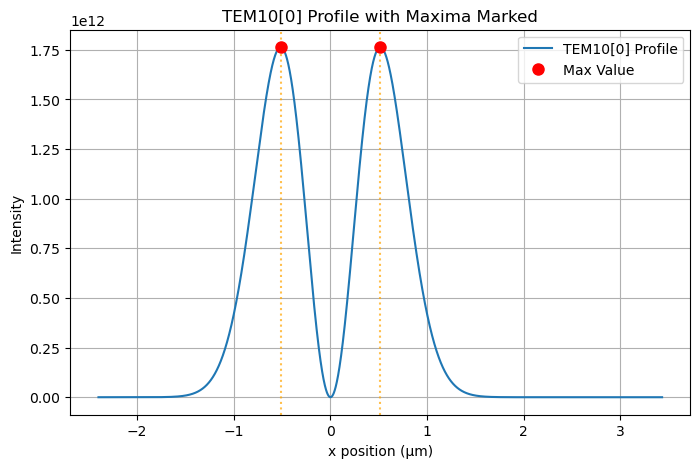

[-0.5154282474240978, 0.5157724726479094]


In [6]:
all_max_indices = []
all_max_xpos_um = []
all_max_distance_um = []

for i in range(len(TEM10)):
    x_pos = x_pos_list[i]  # Use the saved x_pos for each profile
    max_indices = np.argsort(TEM10[i])[-2:]
    max_indices = np.sort(max_indices)
    all_max_indices.append(max_indices.tolist())
    max_xpos_um = (x_pos[max_indices]*1e6).tolist()
    all_max_xpos_um.append(max_xpos_um)
    # Calculate distance between the two maxima (in microns)
    max_distance_um = abs(max_xpos_um[1] - max_xpos_um[0])
    all_max_distance_um.append(max_distance_um)
    print(f"TEM10[{i}] distance between maxima (um):", max_distance_um)

# Example: access max x positions and distance for the first profile
# print(all_max_xpos_um[0], all_max_distance_um[0])

# Optional: plot for the first profile
plt.figure(figsize=(8, 5))
x_pos = x_pos_list[0]  # Use the saved x_pos for the first profile
plt.plot(x_pos * 1e6, TEM10[0], label='TEM10[0] Profile')
for idx in all_max_indices[0]:
    plt.axvline(x=x_pos[idx]*1e6, color='orange', linestyle=':', alpha=0.7)
    plt.plot(x_pos[idx]*1e6, TEM10[0][idx], 'ro', markersize=8, label='Max Value' if idx == all_max_indices[0][0] else "")
plt.xlabel('x position (µm)')
plt.ylabel('Intensity')
plt.title('TEM10[0] Profile with Maxima Marked')
plt.legend()
plt.grid(True)
plt.show()

print(all_max_xpos_um[0])

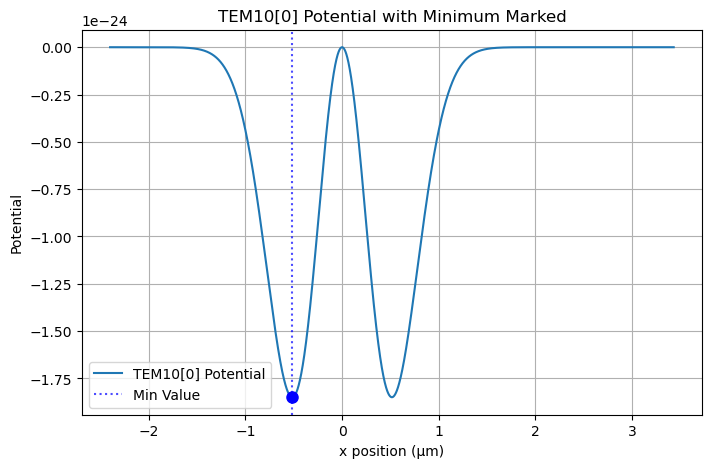

-0.5154282474240978 -1.8494572831992002e-24


In [7]:
all_min_indices = []
all_min_xpos_um = []
all_min_values = []

for i in range(len(tem10_potentials)):
    x_pos = x_pos_list[i]  # Use the saved x_pos for each profile
    min_index = np.argmin(tem10_potentials[i])
    all_min_indices.append(int(min_index))
    min_xpos_um = x_pos[min_index] * 1e6  # Convert to microns
    all_min_xpos_um.append(min_xpos_um)
    min_value = tem10_potentials[i][min_index]
    all_min_values.append(min_value)
    #print(f"TEM10[{i}] min index: {min_index}")
    #print(f"TEM10[{i}] min x position (um): {min_xpos_um}")
    #print(f"TEM10[{i}] min value: {min_value}")

# Example: access min x position and value for the first profile
# print(all_min_xpos_um[0], all_min_values[0])

# Optional: plot for the first profile
plt.figure(figsize=(8, 5))
x_pos = x_pos_list[0]  # Use the saved x_pos for the first profile
plt.plot(x_pos * 1e6, tem10_potentials[0], label='TEM10[0] Potential')
plt.axvline(x=all_min_xpos_um[0], color='blue', linestyle=':', alpha=0.7, label='Min Value')
plt.plot(all_min_xpos_um[0], all_min_values[0], 'bo', markersize=8)
plt.xlabel('x position (µm)')
plt.ylabel('Potential')
plt.title('TEM10[0] Potential with Minimum Marked')
plt.legend()
plt.grid(True)
plt.show()

print(all_min_xpos_um[0], all_min_values[0])

363.36993699369964


R-Squared value 0.9966574614824686
[-1.84639839e-24  1.28391401e-11  5.21620438e-07]
Fit Frequency [2Pi MHz] 3.130773733752887
Center of Node [nm] 521.620437643837
515.4808434849931


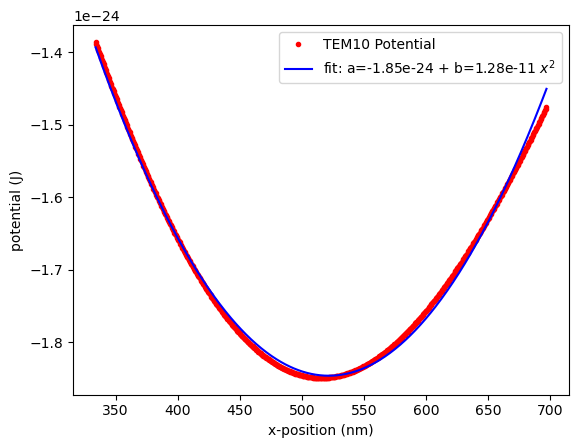

In [8]:
range_width = w0_array[0] * 0.5  # Total range
num_points = 10000
center = w0_array[0] / np.sqrt(2)  # Center is w0/sqrt(2)

# Use the original x_pos for the first profile, but restrict to a window around the minimum
x_pos_full = x_pos_list[0]
potential_full = tem10_potentials[0]

# Find indices within the desired window
window_mask = (x_pos_full >= center - range_width/2) & (x_pos_full <= center + range_width/2)
x_pos = x_pos_full[window_mask]
ydata = potential_full[window_mask]

print((max(x_pos) - min(x_pos)) * 1e9)

plt.plot(x_pos * 1e9, ydata, 'r.', label="TEM10 Potential")

def fitting_function(x, a, b, x0):
    return a + b * (x - x0) ** 2

xdata = x_pos
popt, pcov = curve_fit(fitting_function, xdata, ydata, p0=[-8.244e-24, 4.5e-10, center])

# Calculate the r-squared value of the fit
residuals = ydata - fitting_function(xdata, *popt)
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((ydata - np.mean(ydata)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value", r_squared)

# Calculate the frequency from the fit
print(popt)
fit_tem = np.sqrt(2 * popt[1] / m)
fit_center = popt[2]
print("Fit Frequency [2Pi MHz]", fit_tem / (2 * pi) * 1e-6)
print("Center of Node [nm]", fit_center * 1e9)
print(w0_array[0]/np.sqrt(2) * 1e9)

plt.plot(xdata * 1e9, fitting_function(xdata, *popt), 'b-', label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("x-position (nm)")
plt.ylabel("potential (J)")
plt.legend()
plt.show()

In [9]:
fit_frequencies_Mhz = []
fit_centers_nm = []
fit_centers_um = []

for i in range(len(tem10_potentials)):
    range_width = w0_array[i] * 0.5
    num_points = 10000
    center = w0_array[i] / np.sqrt(2)  # Use the physical center for the fit
    x_pos_full = x_pos_list[i]
    potential_full = tem10_potentials[i]
    # Restrict to a window around the center
    window_mask = (x_pos_full >= center - range_width/2) & (x_pos_full <= center + range_width/2)
    x_pos = x_pos_full[window_mask]
    ydata = potential_full[window_mask]
    def fitting_function(x, a, b, x0):
        return a + b * (x - x0) ** 2
    xdata = x_pos
    popt, pcov = curve_fit(fitting_function, xdata, ydata, p0=[-8.244e-24, 4.5e-10, center])
    fit_tem = np.sqrt(2 * popt[1] / m)
    fit_center = popt[2]
    fit_frequencies_Mhz.append(fit_tem / (2 * pi) * 1e-6)  # [MHz]
    fit_centers_nm.append(fit_center * 1e9)                 # [nm]
    fit_centers_um.append(fit_center * 1e6)                 # [um]
    # Optionally print the center for each fit
    print(f"w0_array[{i}]/sqrt(2) = {center} m, {center*1e9} nm")

print("Fit frequencies [2Pi MHz]:", fit_frequencies_Mhz)
print("Centers of node [nm]:", fit_centers_nm)
print("Centers of node [um]:", fit_centers_um)
print("distance between maxima [um]:", all_max_distance_um)

w0_array[0]/sqrt(2) = 5.154808434849931e-07 m, 515.4808434849931 nm
w0_array[1]/sqrt(2) = 5.199970883035263e-07 m, 519.9970883035263 nm
w0_array[2]/sqrt(2) = 5.245133331220595e-07 m, 524.5133331220594 nm
w0_array[3]/sqrt(2) = 5.290295779405927e-07 m, 529.0295779405927 nm
w0_array[4]/sqrt(2) = 5.335458227591258e-07 m, 533.5458227591258 nm
w0_array[5]/sqrt(2) = 5.38062067577659e-07 m, 538.062067577659 nm
w0_array[6]/sqrt(2) = 5.425783123961921e-07 m, 542.5783123961921 nm
w0_array[7]/sqrt(2) = 5.470945572147254e-07 m, 547.0945572147253 nm
w0_array[8]/sqrt(2) = 5.516108020332585e-07 m, 551.6108020332584 nm
w0_array[9]/sqrt(2) = 5.561270468517917e-07 m, 556.1270468517918 nm
w0_array[10]/sqrt(2) = 5.606432916703248e-07 m, 560.6432916703249 nm
w0_array[11]/sqrt(2) = 5.65159536488858e-07 m, 565.1595364888581 nm
w0_array[12]/sqrt(2) = 5.696757813073913e-07 m, 569.6757813073913 nm
w0_array[13]/sqrt(2) = 5.741920261259244e-07 m, 574.1920261259244 nm
w0_array[14]/sqrt(2) = 5.787082709444576e-07 m,

In [10]:
fit_frequencies_Mhz_y = []
fit_centers_nm_y = []
fit_centers_um_y = []

for i in range(len(tem10_potentials_y)):
    range_width = w0_array[i] * 0.5
    center = 0  # For y, the center is at 0
    y_pos_full = y_pos_list[i]
    potential_full_y = tem10_potentials_y[i]
    # Restrict to a window around the center
    window_mask = (y_pos_full >= center - range_width/2) & (y_pos_full <= center + range_width/2)
    y_pos = y_pos_full[window_mask]
    ydata = potential_full_y[window_mask]
    def fitting_function(y, a, b, y0):
        return a + b * (y - y0) ** 2
    ydata_fit = y_pos
    popt, pcov = curve_fit(fitting_function, ydata_fit, ydata, p0=[-8.244e-24, 4.5e-10, center])
    fit_tem = np.sqrt(2 * popt[1] / m)
    fit_center = popt[2]
    fit_frequencies_Mhz_y.append(fit_tem / (2 * pi) * 1e-6)  # [MHz]
    fit_centers_nm_y.append(fit_center * 1e9)                 # [nm]
    fit_centers_um_y.append(fit_center * 1e6)                 # [um]
    print(f"w0_array[{i}] y-center = {center} m, {center*1e9} nm")

print("Fit frequencies Y [2Pi MHz]:", fit_frequencies_Mhz_y)
print("Centers of node Y [nm]:", fit_centers_nm_y)
print("Centers of node Y [um]:", fit_centers_um_y)

w0_array[0] y-center = 0 m, 0.0 nm
w0_array[1] y-center = 0 m, 0.0 nm
w0_array[2] y-center = 0 m, 0.0 nm
w0_array[3] y-center = 0 m, 0.0 nm
w0_array[4] y-center = 0 m, 0.0 nm
w0_array[5] y-center = 0 m, 0.0 nm
w0_array[6] y-center = 0 m, 0.0 nm
w0_array[7] y-center = 0 m, 0.0 nm
w0_array[8] y-center = 0 m, 0.0 nm
w0_array[9] y-center = 0 m, 0.0 nm
w0_array[10] y-center = 0 m, 0.0 nm
w0_array[11] y-center = 0 m, 0.0 nm
w0_array[12] y-center = 0 m, 0.0 nm
w0_array[13] y-center = 0 m, 0.0 nm
w0_array[14] y-center = 0 m, 0.0 nm
w0_array[15] y-center = 0 m, 0.0 nm
w0_array[16] y-center = 0 m, 0.0 nm
w0_array[17] y-center = 0 m, 0.0 nm
w0_array[18] y-center = 0 m, 0.0 nm
w0_array[19] y-center = 0 m, 0.0 nm
w0_array[20] y-center = 0 m, 0.0 nm
w0_array[21] y-center = 0 m, 0.0 nm
w0_array[22] y-center = 0 m, 0.0 nm
w0_array[23] y-center = 0 m, 0.0 nm
w0_array[24] y-center = 0 m, 0.0 nm
w0_array[25] y-center = 0 m, 0.0 nm
w0_array[26] y-center = 0 m, 0.0 nm
w0_array[27] y-center = 0 m, 0.0 nm
w0

/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


w0_array[42] = 9.97251256281407e-07 m
248.14092665547963
R-Squared value 0.9999841816365289
Fit parameters: [-9.88262525e-25  1.96120826e-12  2.20399215e-17]
Fit Frequency [2Pi MHz] 1.2236171901215738
Center of Node [nm] 2.2039921491509005e-08
0.0


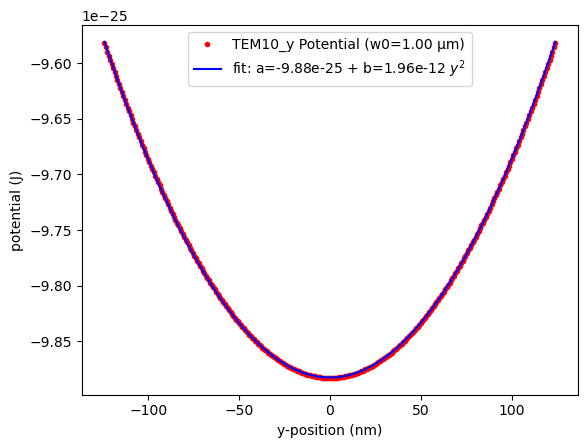

In [11]:
# Find the index in w0_array that is closest to 1e-6
target_w0 = 1e-6
idx = np.argmin(np.abs(w0_array - target_w0))

range_width = w0_array[idx] * 0.25  # Total range
num_points = 10000
center = 0  # For y, the center is at 0

# Use the original y_pos for the selected profile, but restrict to a window around the center
y_pos_full = y_pos_list[idx]
potential_full_y = tem10_potentials_y[idx]

# Find indices within the desired window
window_mask = (y_pos_full >= center - range_width/2) & (y_pos_full <= center + range_width/2)
y_pos = y_pos_full[window_mask]
ydata = potential_full_y[window_mask]

print(f"w0_array[{idx}] = {w0_array[idx]} m")
print((max(y_pos) - min(y_pos)) * 1e9)

plt.plot(y_pos * 1e9, ydata, 'r.', label=f"TEM10_y Potential (w0={w0_array[idx]*1e6:.2f} µm)")

def fitting_function(y, a, b, y0):
    return a + b * (y - y0) ** 2

ydata_fit = y_pos
popt, pcov = curve_fit(fitting_function, ydata_fit, ydata, p0=[-8.244e-24, 4.5e-10, center])

# Calculate the r-squared value of the fit
residuals = ydata - fitting_function(ydata_fit, *popt)
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((ydata - np.mean(ydata)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value", r_squared)

# Calculate the frequency from the fit
print("Fit parameters:", popt)
fit_tem = np.sqrt(2 * popt[1] / m)
fit_center = popt[2]
print("Fit Frequency [2Pi MHz]", fit_tem / (2 * pi) * 1e-6)
print("Center of Node [nm]", fit_center * 1e9)
print(center * 1e9)

plt.plot(ydata_fit * 1e9, fitting_function(ydata_fit, *popt), 'b-', label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $y^2$')
plt.xlabel("y-position (nm)")
plt.ylabel("potential (J)")
plt.legend()
plt.show()

Gaussian radial frequency [2Pi MHz]: 1.015445120354934
Gaussian R-Squared value 0.9999999738957078
Gaussian Fit Frequency [2 Pi x kHz] 1015.1711022107061
Gaussian Analytical Frequency [2 Pi x MHz] 1.015445120354934
Ratio of Fit to Analytical Frequencies 0.9997301497257358


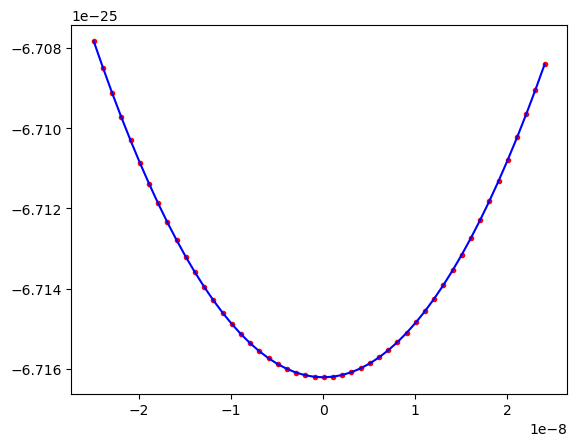

In [12]:
P0 = 1 
w0 = 9.97251256281407e-07
U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
gaussian_freq = omega_tweezer_r(U, w0, m)
print("Gaussian radial frequency [2Pi MHz]:", gaussian_freq * 1e-6 / (2 * np.pi))

# --- Gaussian beam fit ---
x_pos = np.arange(-0.025 * w0, 0.025 * w0, 0.001e-6)
wz = beam_propogation(w0, 0, tweezer_wavelength)
y_pos = 0
gaussian_intensity = intensity(x_pos, y_pos, P0, wz)
gaussian_potential = potential_position_dependent(omega_res, linewidths, omega_tweezer, gaussian_intensity)

def quadratic(x, a, b):
    return a + b * (x ** 2)

xdata = x_pos
ydata = gaussian_potential
popt, pcov = curve_fit(quadratic, xdata, ydata)
residuals = ydata - quadratic(xdata, *popt)
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((ydata - np.mean(ydata)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print("Gaussian R-Squared value", r_squared)
fit = np.sqrt(2 * popt[1] / m)
print("Gaussian Fit Frequency [2 Pi x kHz]", fit * 1e-3 / (2 * pi))
U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
test = tweezer_optical_potential_to_trap_frequency(tweezer_wavelength, linewidths, omega_res, P0, w0, m, U)
print("Gaussian Analytical Frequency [2 Pi x MHz]", test[0] * 1e-6 / (2 * pi))
print("Ratio of Fit to Analytical Frequencies", fit / test[0])

plt.plot(xdata, ydata, 'r.', label="Gaussian Data")
plt.plot(xdata, quadratic(xdata, *popt), 'b-', label=f'Gaussian fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')


In [13]:
N = 10
omega_a_list = np.linspace(0.00001e6*2*np.pi, 6e6*2*np.pi, 15000)
all_spacings = []

for omega_a in omega_a_list:
    spacing = ion_spacing(N, omega_a)
    all_spacings.append(spacing[1])  # Only save the second list (inter-ion spacings)

all_spacings = np.array(all_spacings)  # shape: (len(omega_a_list), N-1)

print(all_spacings[0,3],all_spacings[0,0])  # Print the spacing for the first omega_a
print(all_spacings[10,3],all_spacings[10,3])  # Print the spacing for the 11th omega_a
print(all_spacings[:,3] - all_spacings[:,0])  # Print the difference between the 4th and 1st spacing for all omega_a


0.005479604389442647 0.007388191746327478
0.00010076294450439209 0.00010076294450439209
[-1.90858736e-03 -1.60510868e-04 -1.01945981e-04 ... -2.68318006e-07
 -2.68306079e-07 -2.68294154e-07]


In [14]:
for i in range(len(all_max_distance_um)):
    # Use the middle column instead of the first column
    middle_col = all_spacings[:, 3] * 1e6
    if np.isclose(middle_col, all_max_distance_um[i], atol=0.01).any():
        print(f"Found a match for {all_max_distance_um[i]} um in the middle column of all_spacings.")
    else:
        print(f"No match found for {all_max_distance_um[i]} um in the middle column of all_spacings.")

Found a match for 1.031200720072007 um in the middle column of all_spacings.
Found a match for 1.0402353039324033 um in the middle column of all_spacings.
Found a match for 1.0492698877927995 um in the middle column of all_spacings.
Found a match for 1.0583044716531957 um in the middle column of all_spacings.
Found a match for 1.0673390555135915 um in the middle column of all_spacings.
Found a match for 1.0763736393739878 um in the middle column of all_spacings.
Found a match for 1.0854082232343838 um in the middle column of all_spacings.
Found a match for 1.0944428070947803 um in the middle column of all_spacings.
Found a match for 1.1034773909551763 um in the middle column of all_spacings.
Found a match for 1.1125119748155718 um in the middle column of all_spacings.
Found a match for 1.121546558675968 um in the middle column of all_spacings.
Found a match for 1.1305811425363643 um in the middle column of all_spacings.
Found a match for 1.1396157263967606 um in the middle column of al

In [15]:
matches_info = []

for i in range(len(all_max_distance_um)):
    matches = np.isclose(all_spacings[:, 3]*1e6, all_max_distance_um[i], atol=0.1)
    fit_freq = fit_frequencies_Mhz[i] if i < len(fit_frequencies_Mhz) else None
    if matches.any():
        match_indices = np.where(matches)[0]
        # Only save the first match for each value in all_max_distance_um
        idx = match_indices[0]
        info = {
            "distance_um": all_max_distance_um[i],
            "index": int(idx),
            "spacing_value_um": float(all_spacings[idx, 0]*1e6),
            "match": True,
            "fit_frequency_Mhz": fit_freq,
            "omega_a_value": float(omega_a_list[idx])
        }
        matches_info.append(info)
        print(f"Found a match for {all_max_distance_um[i]} um in the first column of all_spacings at index {idx}.")
        print(f"all_spacings[{idx}, 0]*1e6 = {all_spacings[idx, 0]*1e6} um")
        print(f"omega_a_list[{idx}] = {omega_a_list[idx]}")
    else:
        info = {
            "distance_um": all_max_distance_um[i],
            "index": None,
            "spacing_value_um": None,
            "match": False,
            "fit_frequency_Mhz": fit_freq,
            "omega_a_value": None
        }
        matches_info.append(info)
        print(f"No match found for {all_max_distance_um[i]} um in the first column of all_spacings.")

# Now matches_info contains only the first match for each value in all_max_distance_um

Found a match for 1.031200720072007 um in the first column of all_spacings at index 8428.
all_spacings[8428, 0]*1e6 = 1.5252070375296365 um
omega_a_list[8428] = 21183314.05304113
Found a match for 1.0402353039324033 um in the first column of all_spacings at index 8328.
all_spacings[8328, 0]*1e6 = 1.5373921663032697 um
omega_a_list[8328] = 20931970.30338299
Found a match for 1.0492698877927995 um in the first column of all_spacings at index 8230.
all_spacings[8230, 0]*1e6 = 1.5495725258005424 um
omega_a_list[8230] = 20685653.42871801
Found a match for 1.0583044716531957 um in the first column of all_spacings at index 8134.
all_spacings[8134, 0]*1e6 = 1.5617409886240243 um
omega_a_list[8134] = 20444363.4290462
Found a match for 1.0673390555135915 um in the first column of all_spacings at index 8040.
all_spacings[8040, 0]*1e6 = 1.5738901274664971 um
omega_a_list[8040] = 20208100.304367546
Found a match for 1.0763736393739878 um in the first column of all_spacings at index 7948.
all_spacin

In [16]:
matches_info

[{'distance_um': 1.031200720072007,
  'index': 8428,
  'spacing_value_um': 1.5252070375296365,
  'match': True,
  'fit_frequency_Mhz': 3.130773733752887,
  'omega_a_value': 21183314.05304113},
 {'distance_um': 1.0402353039324033,
  'index': 8328,
  'spacing_value_um': 1.5373921663032697,
  'match': True,
  'fit_frequency_Mhz': 3.0766275084377916,
  'omega_a_value': 20931970.30338299},
 {'distance_um': 1.0492698877927995,
  'index': 8230,
  'spacing_value_um': 1.5495725258005424,
  'match': True,
  'fit_frequency_Mhz': 3.023873907870701,
  'omega_a_value': 20685653.42871801},
 {'distance_um': 1.0583044716531957,
  'index': 8134,
  'spacing_value_um': 1.5617409886240243,
  'match': True,
  'fit_frequency_Mhz': 2.972465580754366,
  'omega_a_value': 20444363.4290462},
 {'distance_um': 1.0673390555135915,
  'index': 8040,
  'spacing_value_um': 1.5738901274664971,
  'match': True,
  'fit_frequency_Mhz': 2.922357170966461,
  'omega_a_value': 20208100.304367546},
 {'distance_um': 1.07637363937

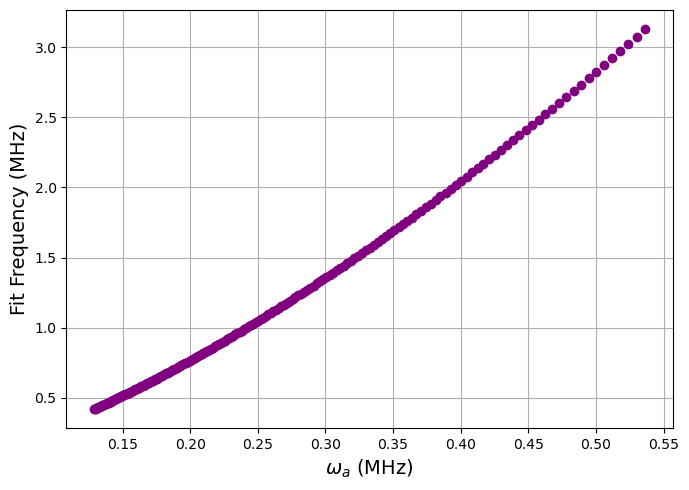

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Filter matches_info to only include entries with a match
matched = [entry for entry in matches_info if entry["match"] and entry["omega_a_value"] is not None and entry["fit_frequency_Mhz"] is not None]

# Extract x and y data
omega_a_values = [entry["omega_a_value"] for entry in matched]
fit_frequencies_Mhz = [entry["fit_frequency_Mhz"] for entry in matched]

# Convert omega_a_values from rad/s to MHz for plotting
omega_a_values_mhz = np.array(omega_a_values) / (2 * np.pi * 1e6)

plt.figure(figsize=(7, 5))
plt.plot(omega_a_values_mhz/(2*pi), fit_frequencies_Mhz, 'o', color='purple',label = "TEM10")
plt.xlabel(r'$\omega_a$ (MHz)', fontsize=14)
plt.ylabel('Fit Frequency (MHz)', fontsize=14)
#plt.title('Fit Frequency vs. $\omega_a$', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
#ok now I just need to calculate the gaussian fit for the same power 
P0 = 1 
U = potential(omega_tweezer,linewidths,omega_res,P0,w0_array)
gaussian_freq = omega_tweezer_r(U,w0_array,m)


In [41]:
P0 = 1/2
U_mid = potential(omega_tweezer, linewidths, omega_res, P0, 1e-6)
gaussian_freq_mid = omega_tweezer_r(U_mid, 1e-6, m)
print(gaussian_freq_mid/(2*pi*1e6))

0.7140862050262728


In [33]:
print(fit_frequencies_Mhz)

[3.130773733752887, 3.0766275084377916, 3.023873907870701, 2.972465580754366, 2.922357170966461, 2.8735052188977463, 2.825868065936388, 2.7794057658100297, 2.7340800002753114, 2.6898540010734973, 2.6466924742477134, 2.6045615318762523, 2.563428622857196, 2.5232624706611517, 2.484033015218526, 2.445711356226994, 2.4082696981706415, 2.371681302257667, 2.3359204373064575, 2.3009623342596406, 2.266783145645395, 2.233359900499943, 2.2006704706956772, 2.168693529888441, 2.1374085229807895, 2.106795629149632, 2.0768357332815186, 2.0475103940016885, 2.0188018175685434, 1.9906928285089898, 1.9631668461609577, 1.9362078582805295, 1.9098003983827994, 1.8839295240946152, 1.8585807965581191, 1.8337402581741595, 1.8093944149490133, 1.785530217467936, 1.7621350449911288, 1.7391966856133705, 1.7167033242556506, 1.6946435242634437, 1.6730062139985558, 1.6517806731141838, 1.6309565194186517, 1.6105236958864975, 1.5904724581956458, 1.5707933635665448, 1.5514772597962865, 1.5325152737499312, 1.51389880226

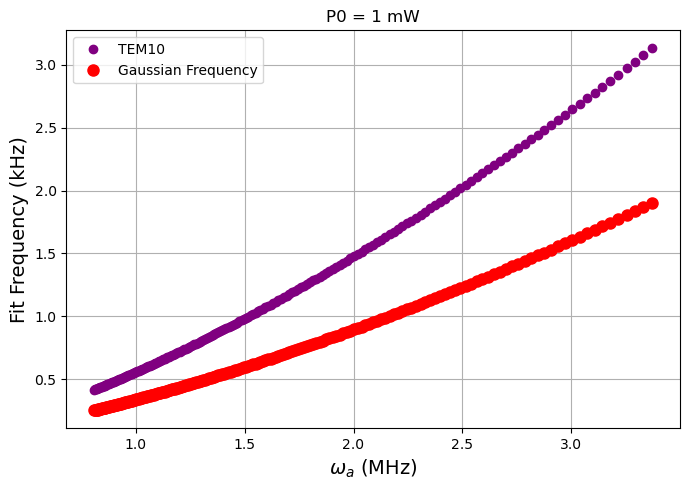

In [34]:
plt.figure(figsize=(7, 5))
plt.plot(omega_a_values_mhz, fit_frequencies_Mhz, 'o', color='purple',label = "TEM10")
plt.plot(omega_a_values_mhz,gaussian_freq/(2*pi)*1e-6, 'ro', markersize=8, label='Gaussian Frequency')
plt.xlabel(r'$\omega_a$ (MHz)', fontsize=14)
plt.ylabel('Fit Frequency (kHz)', fontsize=14)
plt.title('P0 = 1 mW')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

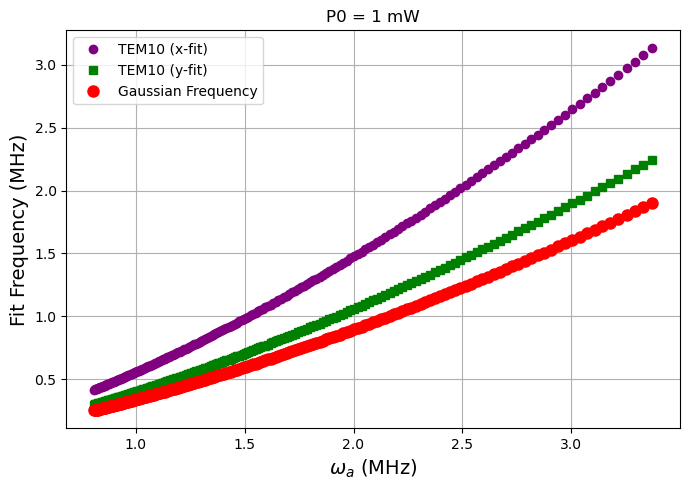

In [35]:
plt.figure(figsize=(7, 5))
plt.plot(omega_a_values_mhz, fit_frequencies_Mhz, 'o', color='purple', label="TEM10 (x-fit)")
plt.plot(omega_a_values_mhz, fit_frequencies_Mhz_y, 's', color='green', label="TEM10 (y-fit)")

# Interpolate or select the Gaussian frequency values to match omega_a_values_mhz
# If you want to plot the Gaussian frequency at the same indices as omega_a_values_mhz:
if len(gaussian_freq) == len(omega_a_values_mhz):
    plt.plot(omega_a_values_mhz, gaussian_freq/(2*pi)*1e-6, 'ro', markersize=8, label='Gaussian Frequency')
else:
    # If gaussian_freq is a single value, repeat it to match the length
    plt.plot(omega_a_values_mhz, np.full_like(omega_a_values_mhz, gaussian_freq[0] * 1e-6), 'o', markersize=8, label='Gaussian Frequency',color = 'red')

plt.xlabel(r'$\omega_a$ (MHz)', fontsize=14)
plt.ylabel('Fit Frequency (MHz)', fontsize=14)
plt.title('P0 = 1 mW')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

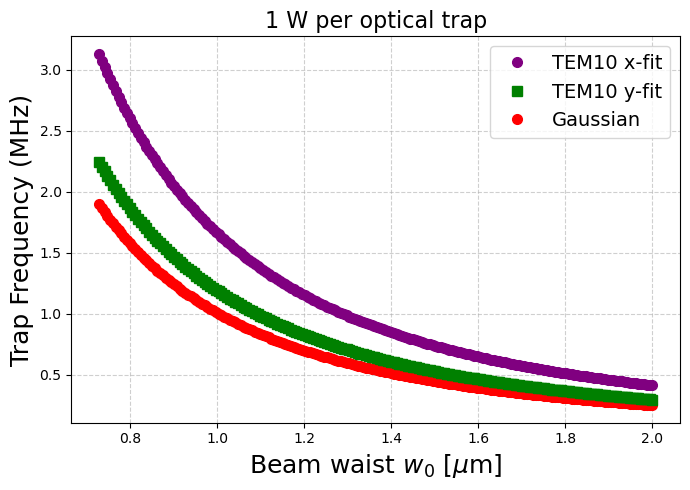

In [36]:
plt.figure(figsize=(7, 5))

# Plot TEM10 fit frequencies (purple circles)
plt.plot(w0_array * 1e6, np.array(fit_frequencies_Mhz), 'o', color='purple', label="TEM10 x-fit", markersize=7, zorder=3)

# Plot TEM10 y-fit frequencies (green squares)
plt.plot(w0_array * 1e6, np.array(fit_frequencies_Mhz_y), 's', color='green', label="TEM10 y-fit", markersize=7, zorder=3)

# Plot Gaussian frequencies (red circles)
plt.plot(w0_array * 1e6, gaussian_freq / (2 * np.pi) * 1e-6, 'o', color='red', label='Gaussian', markersize=7, zorder=2)

plt.xlabel(r'Beam waist $w_0$ [$\mu$m]', fontsize=18)
plt.ylabel('Trap Frequency (MHz)', fontsize=18)
plt.title('1 W per optical trap', fontsize=16)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
max(gaussian_freq / (2 * np.pi)*1e-6)

1.90024931432029

In [27]:
from scipy.optimize import fsolve

def spacing_func(omega_a, target_spacing):
    N = 10
    ueq = ion_spacing(N, omega_a)[0]
    return (ueq[4] - ueq[3]) - target_spacing

# Example: set corresponding_beam_waist to a value in meters (e.g., 1.0e-6 for 1 micron)
corresponding_beam_waist = w0_array[0]*0.8  # <-- set this to your desired value

# Use fsolve to find omega_a that gives the desired spacing
omega_a_solution = fsolve(spacing_func, 2 * np.pi * 1e6, args=(corresponding_beam_waist,))[0]
print("omega_a (MHz):", omega_a_solution/(2*pi*1e6))
print("omega_a (MHz):", omega_a_solution / (2 * np.pi * 1e6))

omega_a (MHz): 9.107465491780445
omega_a (MHz): 9.107465491780445


In [24]:
# Filter all_spacings_filtered and omega_a_list_filtered by TEM10[0] and TEM10[-1] distance between maxima

# Assume all_max_distance_um is already computed and available
tem10_min = all_max_distance_um[0]   # TEM10[0] distance between maxima (in um)
tem10_max = all_max_distance_um[-1]  # TEM10[-1] distance between maxima (in um)

# Filter for spacings within [tem10_min, tem10_max]
mask_tem10 = (all_spacings_filtered * 1e6 >= tem10_min) & (all_spacings_filtered * 1e6 <= tem10_max)
spacings_tem10 = all_spacings_filtered[mask_tem10]
omega_a_tem10 = omega_a_list_filtered[mask_tem10]

plt.figure(figsize=(8, 5))
plt.plot(spacings_tem10 * 1e6, omega_a_tem10 / (2 * np.pi * 1e6), '.', color="#3B39E4")
plt.ylabel(r'$\omega_a$ (MHz)', fontsize=18)
plt.xlabel('Distance between middle two ions [um]', fontsize=18)
#plt.title(f"Filtered for TEM10[0] ({tem10_min:.2f} um) to TEM10[-1] ({tem10_max:.2f} um) maxima spacing")
plt.grid(True)
plt.show()

print("Filtered spacings range [um]:", spacings_tem10[0]*1e6, spacings_tem10[-1]*1e6)

NameError: name 'all_spacings_filtered' is not defined

In [ ]:
print(all_spacings_filtered[-1]*1e6)


0.5832081446226571


In [26]:
N = 10
w_rf_a = 3.8*2*pi*1e6
uueq = ion_spacing(N, w_rf_a)
print("uueq:", uueq)

uueq: [array([-5.24506501e-06, -3.83680636e-06, -2.64988099e-06, -1.55987402e-06,
       -5.15410019e-07,  5.15410019e-07,  1.55987402e-06,  2.64988099e-06,
        3.83680636e-06,  5.24506501e-06]), [1.408258648757763e-06, 1.1869253700333472e-06, 1.0900069743329755e-06, 1.0444639958132417e-06, 1.0308200384806493e-06, 1.0444639958131201e-06, 1.0900069743325026e-06, 1.186925370030987e-06, 1.4082586487776165e-06]]
